# Трансформерные архитектуры для временных рядов с длинной памятью
## Эмпирическое исследование: Facebook (Meta), Boeing, JP Morgan

In [1]:
import os, math, time, warnings, pickle
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import t as t_dist

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False,
                     "axes.spines.right": False})


Device: cuda


In [2]:
INPUT_WINDOW  = 60
BATCH_SIZE    = 64
EPOCHS        = 50
LR            = 1e-4
D_MODEL       = 64
NHEAD         = 8
NUM_LAYERS    = 3
DROPOUT       = 0.1
TEST_SIZE     = 0.30
CLASSICAL_SUB = 20_000
N_PLOT        = 500
ARFIMA_D      = 0.3


---
## 1. Загрузка и осмотр данных

In [3]:
df_raw = pd.read_csv("facebook.csv")
print("Размер:", df_raw.shape)
print("Колонки:", df_raw.columns.tolist())
df_raw.head()


Размер: (160679, 21)
Колонки: ['date', 'minute', 'label', 'high', 'low', 'open', 'close', 'average', 'volume', 'notional', 'numberOfTrades', 'rsi', 'long', 'exit_long', 'short', 'exit_short', 'long_pnl', 'short_pnl', 'total_pnl', 'long_labels', 'short_labels']


,date,minute,label,high,low,open,close,average,volume,notional,...,rsi,long,exit_long,short,exit_short,long_pnl,short_pnl,total_pnl,long_labels,short_labels
0,2019-04-01,09:30,09:30 AM,168.000,167.52,167.925,167.82,167.775,9294.0,1559300.720,...,NaN,NaN,167.925,NaN,167.805,NaN,NaN,0.0,NaN,NaN
1,2019-04-01,09:31,09:31 AM,168.190,167.76,167.760,168.19,167.908,863.0,144904.500,...,100.000000,NaN,167.925,NaN,167.805,NaN,NaN,0.0,NaN,NaN
2,2019-04-01,09:32,09:32 AM,168.630,168.36,168.390,168.36,168.490,2707.0,456101.680,...,100.000000,NaN,167.925,NaN,167.805,NaN,NaN,0.0,NaN,NaN
3,2019-04-01,09:33,09:33 AM,168.135,167.94,168.135,168.04,168.132,5503.0,925229.920,...,46.468401,NaN,167.925,NaN,167.805,NaN,NaN,0.0,NaN,NaN
4,2019-04-01,09:34,09:34 AM,168.200,168.00,168.045,168.01,168.189,15236.0,2562520.845,...,43.215212,NaN,167.925,NaN,167.805,NaN,NaN,0.0,NaN,NaN


In [4]:
display(df_raw[["open","high","low","close","volume"]].describe().round(4))
print("\nПропуски:")
print(df_raw.isnull().sum())


,open,high,low,close,volume
count,150454.0000,153165.0000,153165.0000,160679.0000,160636.0000
mean,212.4161,208.7117,208.5625,211.6910,1196.8937
std,35.9036,45.3878,45.3448,35.4499,2477.4901
min,137.2900,-1.0000,-1.0000,137.3200,0.0000
25%,185.6700,185.1700,185.0600,185.5800,200.0000
50%,200.9300,200.4200,200.3250,200.4050,504.0000
75%,237.7000,237.1000,236.9200,236.1250,1241.0000
max,304.3000,304.6300,304.0600,304.4800,103143.0000



Пропуски:
date                   0
minute                 0
label                 43
high                7514
low                 7514
open               10225
close                  0
average             7514
volume                43
notional              43
numberOfTrades        43
rsi                    1
long              145087
exit_long              1
short             145045
exit_short            14
long_pnl          145087
short_pnl         145050
total_pnl              0
long_labels       145087
short_labels      145050
dtype: int64


---
## 2. Предобработка и признаки

In [5]:
df = df_raw.copy()

# ── парсинг дат ────────────────────────────────────────────────────────────────
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.sort_values("date").reset_index(drop=True)
df = df.set_index("date")

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for c in num_cols:
    df[c] = df[c].replace([np.inf, -np.inf], np.nan).ffill().bfill()

for col in ["high", "low"]:
    df[col] = df[col].replace(0, np.nan).interpolate(method="time")
    df[col] = df[col].rolling(window=5, min_periods=1).mean()

df["returns"]      = df["close"].pct_change()
df["log_returns"]  = np.log(df["close"] / df["close"].shift(1))
df["range_hl"]     = (df["high"] - df["low"]) / df["close"]
df["range_co"]     = (df["close"] - df["open"]) / df["open"]
df["volatility_20"]= df["returns"].rolling(20).std()
df["ma_10"]        = df["close"].rolling(10).mean()
df["ma_20"]        = df["close"].rolling(20).mean()
df["ma_ratio"]     = df["ma_10"] / df["ma_20"]
df["volume_ma_20"] = df["volume"].rolling(20).mean()
df["volume_ratio"] = df["volume"] / df["volume_ma_20"]

for lag in [1, 2, 3, 5]:
    df[f"close_lag_{lag}"]   = df["close"].shift(lag)
    df[f"returns_lag_{lag}"] = df["returns"].shift(lag)

df = df.replace([np.inf, -np.inf], np.nan).ffill().bfill()

print(f"Итого строк: {len(df)}, пропусков: {df.isnull().sum().sum()}")
print(f"Период: {df.index.min().date()} — {df.index.max().date()}")

Итого строк: 160679, пропусков: 0
Период: 2019-04-01 — 2020-11-27


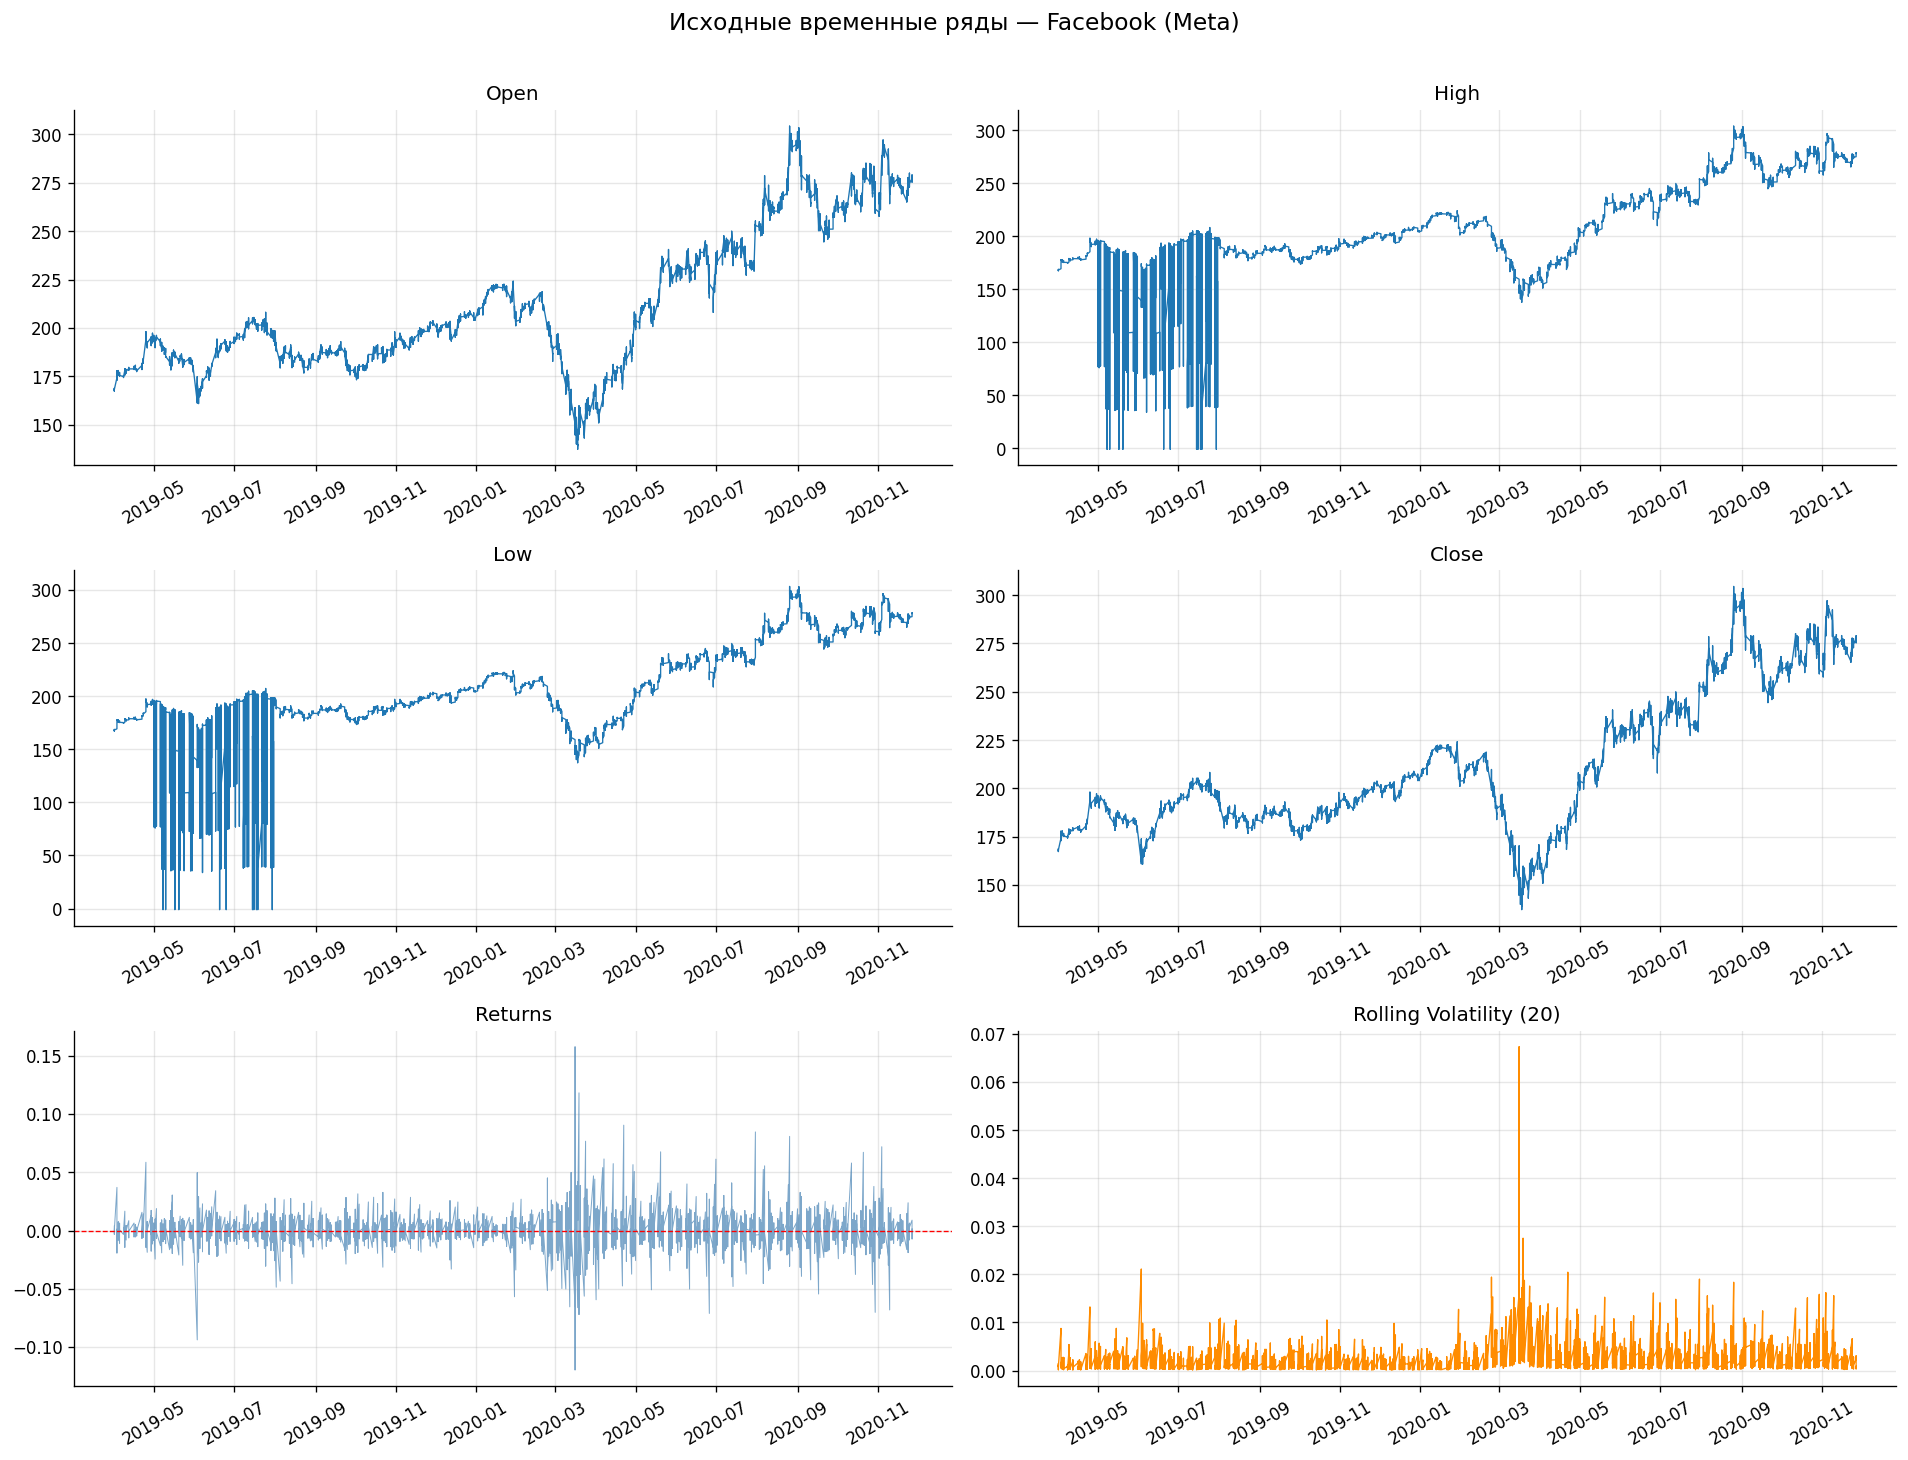

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

for ax, col in zip(axes.ravel()[:4], ["open", "high", "low", "close"]):
    ax.plot(df.index, df[col], linewidth=0.8)
    ax.set_title(col.capitalize(), fontsize=12)
    ax.tick_params(axis="x", rotation=30)

axes[2, 0].plot(df.index, df["returns"], linewidth=0.6, alpha=0.7, color="steelblue")
axes[2, 0].axhline(0, color="red", linewidth=0.8, linestyle="--")
axes[2, 0].set_title("Returns")
axes[2, 0].tick_params(axis="x", rotation=30)

axes[2, 1].plot(df.index, df["volatility_20"], linewidth=0.8, color="darkorange")
axes[2, 1].set_title("Rolling Volatility (20)")
axes[2, 1].tick_params(axis="x", rotation=30)

plt.suptitle("Исходные временные ряды — Facebook (Meta)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 3. Тесты на длинную память

In [7]:
def hurst_rs(x):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    N = len(x)
    if N < 200: return np.nan
    y = x - x.mean()
    sizes = np.unique(np.floor(
        np.logspace(np.log10(50), np.log10(N//2), 20)).astype(int))
    valid_sizes, rs_vals = [], []
    for n in sizes:
        m = N // n
        if m < 4: continue
        seg = y[:m*n].reshape(m, n)
        cs  = np.cumsum(seg - seg.mean(axis=1, keepdims=True), axis=1)
        R   = cs.max(axis=1) - cs.min(axis=1)
        S   = seg.std(axis=1, ddof=1)
        ok  = S > 0
        if ok.sum() >= 2:
            rs_vals.append(np.mean(R[ok] / S[ok]))
            valid_sizes.append(n)
    if len(valid_sizes) < 4: return np.nan
    return np.polyfit(np.log(valid_sizes), np.log(rs_vals), 1)[0]


def gph_test(x, m_frac=0.5):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    N = len(x)
    if N < 200: return (np.nan,)*4
    m = max(10, min(int(N**m_frac), N//2-1))
    y = x - x.mean()
    I = (np.abs(np.fft.fft(y)[1:m+1])**2) / (2*np.pi*N)
    freq = 2*np.pi*np.arange(1, m+1) / N
    reg  = np.log(4*np.sin(freq/2)**2)
    Y    = np.log(np.where(I > 0, I, 1e-300))
    X    = np.column_stack([np.ones(m), -reg])
    b, res, _, _ = np.linalg.lstsq(X, Y, rcond=None)
    d_hat = b[1]
    dof   = m - 2
    if dof < 1: return d_hat, np.nan, np.nan, np.nan
    sigma2 = (res[0]/dof) if len(res)>0 else np.sum((Y - X@b)**2)/dof
    se = np.sqrt(sigma2 * np.linalg.pinv(X.T@X)[1,1])
    t_stat = d_hat / se
    p_val  = 2 * t_dist.sf(abs(t_stat), df=dof)
    return d_hat, se, t_stat, p_val


def lo_test(x, q=10):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    N = len(x)
    if N < 200: return np.nan
    r  = x - x.mean()
    y  = np.cumsum(r)
    R  = y.max() - y.min()
    s2 = np.var(r, ddof=0)
    for k in range(1, q+1):
        s2 += 2*(1 - k/(q+1))*np.mean(r[k:]*r[:-k])
    return R / np.sqrt(N*s2) if s2 > 0 else np.nan


=== ACF/PACF ===


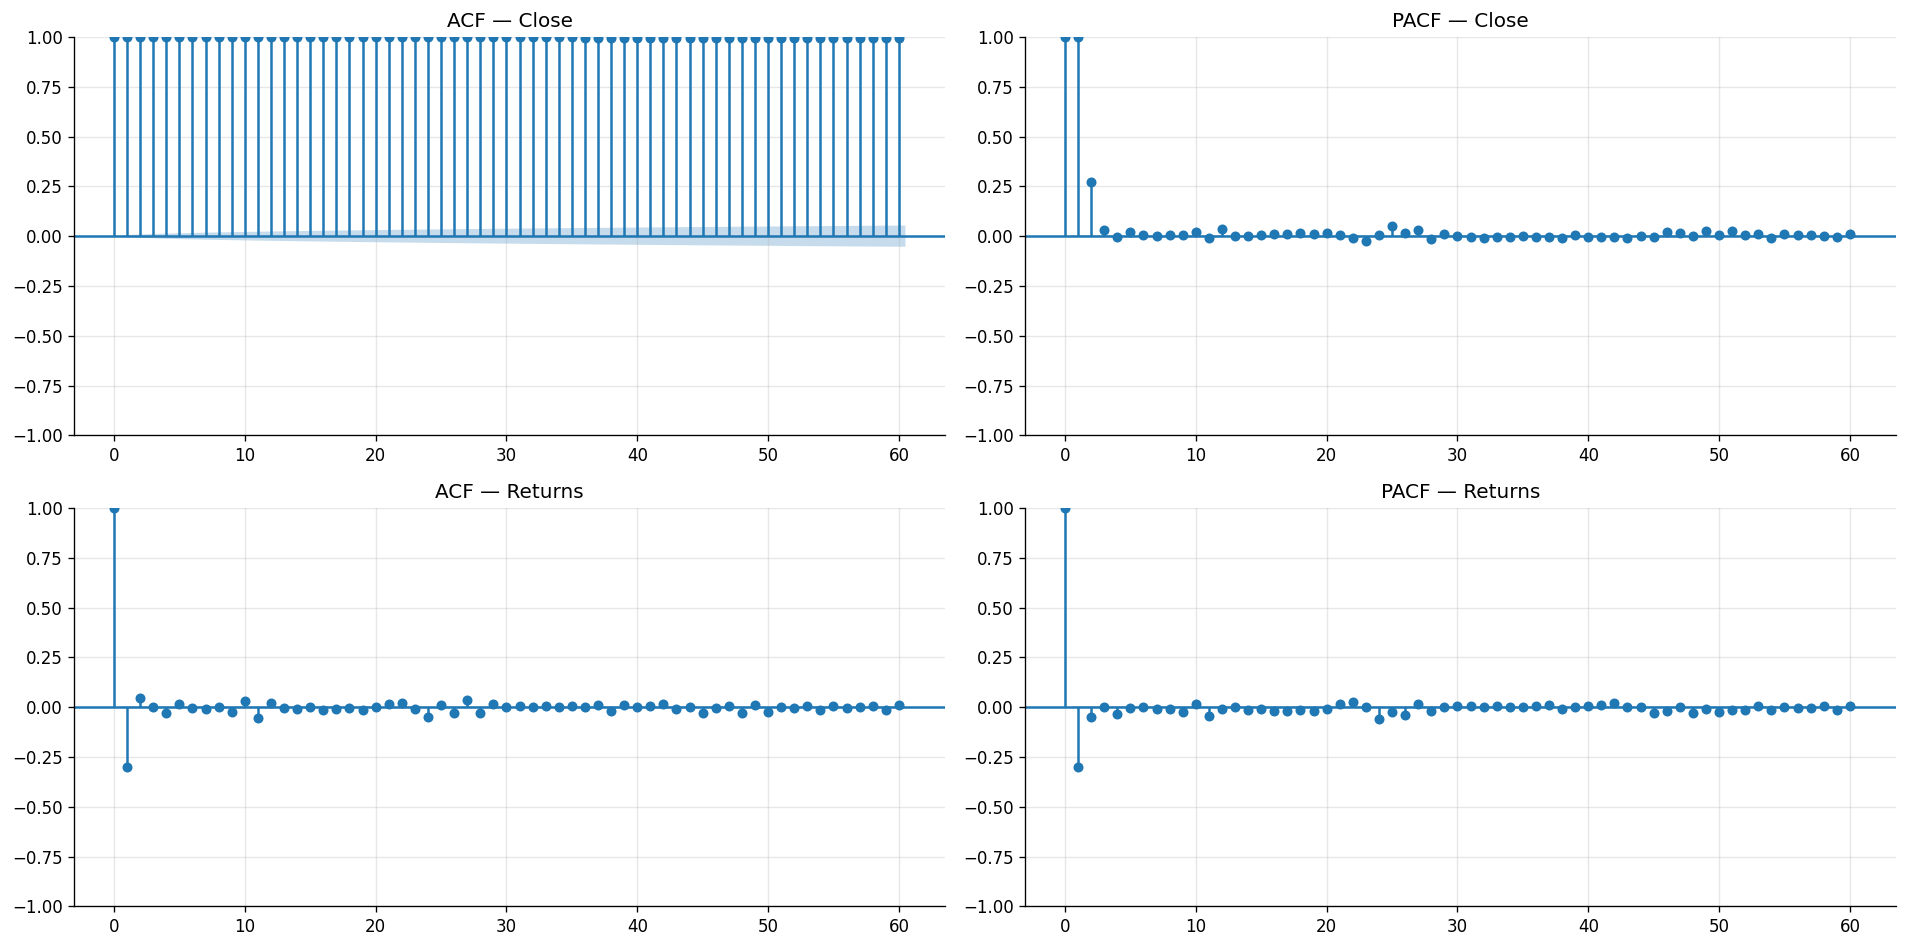

In [8]:
print("=== ACF/PACF ===")
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
plot_acf(df["close"].dropna(),   lags=60, ax=axes[0,0], title="ACF — Close")
plot_pacf(df["close"].dropna(),  lags=60, ax=axes[0,1], title="PACF — Close", method="ywm")
plot_acf(df["returns"].dropna(), lags=60, ax=axes[1,0], title="ACF — Returns")
plot_pacf(df["returns"].dropna(),lags=60, ax=axes[1,1], title="PACF — Returns", method="ywm")
plt.tight_layout(); plt.show()


In [9]:
print("=== Сводная таблица тестов на длинную память ===\n")
rows = []
for col_name in ["close", "returns", "log_returns"]:
    s = df[col_name].dropna().values
    h = hurst_rs(s)
    d, d_se, d_t, d_p = gph_test(s)
    q_lo = max(5, int(len(s)**0.25))
    lo   = lo_test(s, q=q_lo)
    sub  = s[-30_000:] if len(s) > 30_000 else s
    try:    adf_p = adfuller(sub, maxlag=30, autolag="AIC")[1]
    except: adf_p = np.nan
    if   h > 1.0:  interp = "нестационарен → тест к returns"
    elif h > 0.55: interp = "длинная память"
    elif h > 0.45: interp = "нет памяти"
    else:          interp = "антиперсистентность"
    rows.append({"Ряд": col_name,
                 "H": round(h,4), "d (GPH)": round(d,4),
                 "GPH p": round(d_p,4) if not np.isnan(d_p) else np.nan,
                 f"Lo (q={q_lo})": round(lo,4) if not np.isnan(lo) else np.nan,
                 "ADF p": round(adf_p,4), "Вывод": interp})
    print(f"  {col_name}: H={h:.3f}, d={d:.3f} (p={d_p:.3f}), "
          f"Lo={lo:.3f}, ADF_p={adf_p:.4f}")
display(pd.DataFrame(rows))
print("\nLo крит. зн. (5%): [0.809, 1.862] — Vn > 1.862 → длинная память")


=== Сводная таблица тестов на длинную память ===

  close: H=1.018, d=0.942 (p=0.000), Lo=35.768, ADF_p=0.0216
  returns: H=0.434, d=-0.100 (p=0.004), Lo=1.002, ADF_p=0.0000
  log_returns: H=0.435, d=-0.087 (p=0.010), Lo=0.869, ADF_p=0.0000


,Ряд,H,d (GPH),GPH p,Lo (q=20),ADF p,Вывод
0,close,1.0180,0.9423,0.0000,35.7682,0.0216,нестационарен → тест к returns
1,returns,0.4336,-0.1001,0.0035,1.0021,0.0000,антиперсистентность
2,log_returns,0.4352,-0.0874,0.0098,0.8686,0.0000,антиперсистентность



Lo крит. зн. (5%): [0.809, 1.862] — Vn > 1.862 → длинная память


---
## 4. Признаки и масштабирование

Признаков: 24


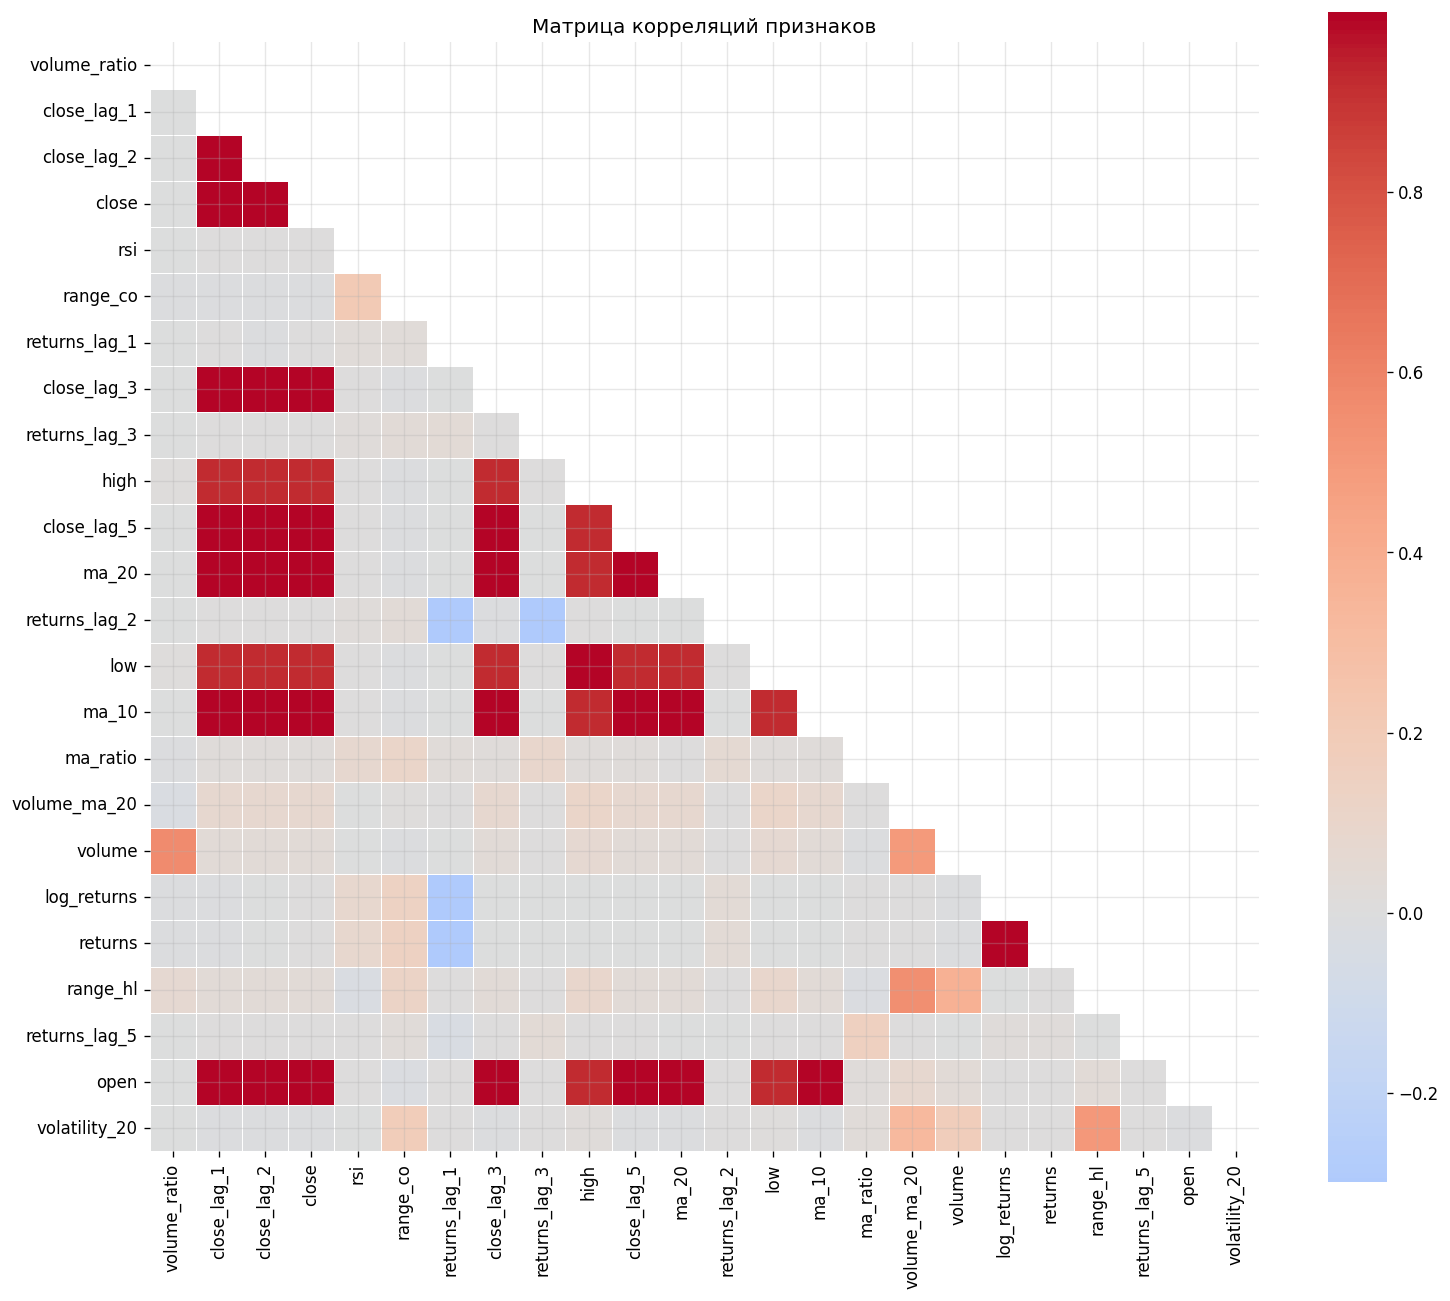


Топ корреляций с close:
open            0.999960
close_lag_1     0.999853
close_lag_2     0.999793
ma_10           0.999771
close_lag_3     0.999719
close_lag_5     0.999579
ma_20           0.999567
low             0.926847
high            0.926815
volume_ma_20    0.074362
Name: close, dtype: float64


In [10]:
base_features = [
    "open", "high", "low", "close",
    "volume", "rsi",
    "returns", "log_returns",
    "range_hl", "range_co", "volatility_20",
    "ma_10", "ma_20", "ma_ratio",
    "volume_ma_20", "volume_ratio",
    "close_lag_1", "close_lag_2", "close_lag_3", "close_lag_5",
    "returns_lag_1", "returns_lag_2", "returns_lag_3", "returns_lag_5",
]
features = [c for c in base_features if c in df.columns]
TARGET   = "close"
print(f"Признаков: {len(features)}")

corr = df[list(set(features+[TARGET]))].corr(numeric_only=True)
plt.figure(figsize=(13,11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, annot=False,
            linewidths=0.3, square=True)
plt.title("Матрица корреляций признаков"); plt.tight_layout(); plt.show()
print("\nТоп корреляций с close:")
print(corr[TARGET].drop(TARGET,errors="ignore").abs()
                  .sort_values(ascending=False).head(10))


In [11]:
split_idx = int(len(df)*(1-TEST_SIZE))
train_df  = df.iloc[:split_idx].copy()
test_df   = df.iloc[split_idx:].copy()
print(f"Train: {train_df.shape} | Test: {test_df.shape}")
print(f"Train: {train_df.index.min().date()} — {train_df.index.max().date()}")
print(f"Test:  {test_df.index.min().date()} — {test_df.index.max().date()}")

feature_scalers = {}
train_sc, test_sc = [], []
for col in features:
    sc = RobustScaler()
    feature_scalers[col] = sc
    train_sc.append(sc.fit_transform(train_df[[col]]).flatten())
    test_sc.append(sc.transform(test_df[[col]]).flatten())
train_matrix = np.column_stack(train_sc)
test_matrix  = np.column_stack(test_sc)

target_scaler = MinMaxScaler()
y_train_raw   = train_df[TARGET].values
y_test_raw    = test_df[TARGET].values
close_train_raw = y_train_raw
close_test_raw  = y_test_raw
y_train_sc = target_scaler.fit_transform(y_train_raw.reshape(-1,1)).flatten()
y_test_sc  = target_scaler.transform(y_test_raw.reshape(-1,1)).flatten()

def inv_target(x):
    return target_scaler.inverse_transform(np.array(x).reshape(-1,1)).flatten()

print(f"\nclose train: [{y_train_raw.min():.2f}, {y_train_raw.max():.2f}]")
print(f"scaled:      [{y_train_sc.min():.4f}, {y_train_sc.max():.4f}]")


Train: (112475, 38) | Test: (48204, 38)
Train: 2019-04-01 — 2020-06-02
Test:  2020-06-03 — 2020-11-27

close train: [137.32, 240.57]
scaled:      [0.0000, 1.0000]


In [12]:
def make_sequences(X, y, window):
    Xs, ys = [], []
    for i in range(len(X)-window):
        Xs.append(X[i:i+window])
        ys.append(y[i+window])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

X_train, y_train = make_sequences(train_matrix, y_train_sc, INPUT_WINDOW)
X_test,  y_test  = make_sequences(test_matrix,  y_test_sc,  INPUT_WINDOW)
print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")

class TSDataset(Dataset):
    def __init__(self, X, y):
        self.X, self.y = torch.FloatTensor(X), torch.FloatTensor(y)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_loader = DataLoader(TSDataset(X_train, y_train),
                          batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader  = DataLoader(TSDataset(X_test, y_test),
                          batch_size=BATCH_SIZE, shuffle=False)

print(f"NaN train: {np.isnan(train_matrix).sum()} | NaN test: {np.isnan(test_matrix).sum()}")
print(f"inv_target([0,0.5,1]) = {inv_target([0,0.5,1]).round(2)}")


X_train: (112415, 60, 24)  y_train: (112415,)
X_test:  (48144, 60, 24)   y_test:  (48144,)
NaN train: 0 | NaN test: 0
inv_target([0,0.5,1]) = [137.32 188.94 240.57]


---
## 5. Нейросетевые архитектуры

In [13]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0,d_model,2).float()*(-math.log(10000.0)/d_model))
        pe[:,0::2] = torch.sin(pos*div)
        pe[:,1::2] = torch.cos(pos*div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:,:x.size(1)]


In [14]:
class StandardTransformer(nn.Module):
    """Encoder-only трансформер, полный self-attention O(T²)."""
    def __init__(self, input_dim, d_model=D_MODEL, nhead=NHEAD,
                 num_layers=NUM_LAYERS, dropout=DROPOUT):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos = PositionalEncoding(d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=4*d_model,
            dropout=dropout, batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.head = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, 1))

    def forward(self, x):
        x = self.pos(self.input_proj(x))
        return self.head(self.encoder(x)[:,-1,:]).squeeze(-1)


In [15]:
class ProbSparseAttention(nn.Module):
    """Top-k sparse attention, сложность O(T log T)."""
    def __init__(self, d_model, n_heads=NHEAD, sparsity=0.3):
        super().__init__()
        self.n_heads, self.d_head = n_heads, d_model//n_heads
        self.sparsity = sparsity
        self.scale    = math.sqrt(self.d_head)
        self.q = nn.Linear(d_model, d_model)
        self.k = nn.Linear(d_model, d_model)
        self.v = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

    def forward(self, x):
        B, T, D = x.shape
        H, Dh   = self.n_heads, self.d_head
        def split(t): return t.view(B,T,H,Dh).transpose(1,2)
        Q, K, V = split(self.q(x)), split(self.k(x)), split(self.v(x))
        scores  = torch.matmul(Q, K.transpose(-2,-1)) / self.scale
        k_top   = max(1, int(T*self.sparsity))
        tv, ti  = torch.topk(scores, k_top, dim=-1)
        mask    = torch.full_like(scores, -1e9)
        mask.scatter_(-1, ti, tv)
        out = torch.matmul(torch.softmax(mask, dim=-1), V)
        return self.out_proj(out.transpose(1,2).contiguous().view(B,T,D))


class ProbSparseTransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads=NHEAD, dropout=DROPOUT):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.attn  = ProbSparseAttention(d_model, n_heads)
        self.ff    = nn.Sequential(
            nn.Linear(d_model,4*d_model), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(4*d_model,d_model), nn.Dropout(dropout))
    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        return x + self.ff(self.norm2(x))


class ProbSparseTransformer(nn.Module):
    """Informer-style трансформер с ProbSparse attention, O(T log T)."""
    def __init__(self, input_dim, d_model=D_MODEL, n_heads=NHEAD,
                 num_layers=NUM_LAYERS, dropout=DROPOUT):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos    = PositionalEncoding(d_model)
        self.blocks = nn.ModuleList([
            ProbSparseTransformerBlock(d_model, n_heads, dropout)
            for _ in range(num_layers)])
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.pos(self.input_proj(x))
        for blk in self.blocks: x = blk(x)
        return self.head(self.norm(x[:,-1,:])).squeeze(-1)


In [16]:
class MultiFeatureTransformer(nn.Module):
    """
    Двухпутевой трансформер: temporal path + variate path.

    Temporal path — стандартный self-attention вдоль оси времени (B,T,d).
    Variate path  — self-attention вдоль оси признаков (iTransformer-стиль):
                    транспонируем вход (B,F,T), проецируем F-вектора в d-мерное
                    пространство и учим взаимодействия между признаками.
    Выходы двух путей объединяются через обучаемый скалярный gate.
    """
    def __init__(self, input_dim, seq_len=INPUT_WINDOW,
                 d_model=D_MODEL, nhead=NHEAD,
                 num_layers=NUM_LAYERS, dropout=DROPOUT):
        super().__init__()

        # ── temporal path ──────────────────────────────────────────────
        self.t_proj = nn.Linear(input_dim, d_model)
        self.t_pos  = PositionalEncoding(d_model)
        t_enc = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=4*d_model,
            dropout=dropout, batch_first=True, norm_first=True, activation="gelu")
        self.t_encoder = nn.TransformerEncoder(t_enc, num_layers=num_layers)

        # ── variate path ───────────────────────────────────────────────
        # каждый признак представлен своим time-вектором длины seq_len
        self.v_proj = nn.Linear(seq_len, d_model)
        v_enc = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=4*d_model,
            dropout=dropout, batch_first=True, norm_first=True, activation="gelu")
        self.v_encoder = nn.TransformerEncoder(v_enc, num_layers=num_layers)

        # обучаемый коэффициент смешивания путей
        self.gate = nn.Parameter(torch.tensor(0.5))

        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, 1))

        # инициализация
        for m in [self.t_proj, self.v_proj]:
            nn.init.xavier_uniform_(m.weight)
            nn.init.zeros_(m.bias)

    def forward(self, x):
        # x: (B, T, F)

        # temporal path: attention по оси T
        xt = self.t_pos(self.t_proj(x))         # (B,T,d)
        xt = self.t_encoder(xt)[:,-1,:]         # (B,d) — последний шаг

        # variate path: attention по оси F
        # (B,T,F) → транспозиция → (B,F,T) → линейная проекция по T → (B,F,d)
        xv = self.v_proj(x.transpose(1,2))      # (B,F,d)
        xv = self.v_encoder(xv).mean(dim=1)     # (B,d) — mean-pooling по F

        # взвешенное объединение
        g   = torch.sigmoid(self.gate)
        out = g * xt + (1-g) * xv               # (B,d)
        return self.head(out).squeeze(-1)


In [17]:
class LSTMModel(nn.Module):
    """Двухслойный LSTM baseline."""
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers,
                            batch_first=True, dropout=dropout)
        self.head = nn.Sequential(nn.LayerNorm(hidden_dim), nn.Linear(hidden_dim,1))

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:,-1,:]).squeeze(-1)


In [18]:
def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR, patience=8):
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.MSELoss()
    best_val, best_state, no_improve = float("inf"), None, 0
    history = {"train": [], "val": []}

    for epoch in range(1, epochs+1):
        model.train()
        tl = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            criterion(model(xb), yb).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            tl += criterion(model(xb), yb).item()  # approx
        # точный train loss
        model.eval()
        tl_exact = 0.0
        with torch.no_grad():
            for xb, yb in train_loader:
                tl_exact += criterion(model(xb.to(device)), yb.to(device)).item()
        tl = tl_exact / len(train_loader)

        vl = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                vl += criterion(model(xb.to(device)), yb.to(device)).item()
        vl /= len(val_loader)

        scheduler.step()
        history["train"].append(tl)
        history["val"].append(vl)

        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch {epoch:03d} | train={tl:.6f} | val={vl:.6f}")

        if vl < best_val:
            best_val, no_improve = vl, 0
            best_state = {k: v.cpu().clone() for k,v in model.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stop на эпохе {epoch}")
                break

    model.load_state_dict(best_state)
    return model, history


def predict_torch(model, X, batch_size=256):
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            preds.append(model(torch.FloatTensor(X[i:i+batch_size]).to(device)).cpu().numpy())
    return np.concatenate(preds)


---
## 6. Обучение нейронных сетей

In [19]:
print("="*55); print("Обучение: Standard Transformer"); print("="*55)
t0 = time.time()
standard_transformer, hist_std = train_model(StandardTransformer(len(features)), train_loader, test_loader)
print(f"  Время: {time.time()-t0:.1f}с")


Обучение: Standard Transformer
  Epoch 001 | train=0.000229 | val=0.008635
  Epoch 005 | train=0.000041 | val=0.000543
  Epoch 010 | train=0.000047 | val=0.000622
  Epoch 015 | train=0.000056 | val=0.000363
  Early stop на эпохе 16
  Время: 428.3с


In [20]:
print("="*55); print("Обучение: ProbSparse Transformer"); print("="*55)
t0 = time.time()
probsparse_transformer, hist_prob = train_model(ProbSparseTransformer(len(features)), train_loader, test_loader)
print(f"  Время: {time.time()-t0:.1f}с")


Обучение: ProbSparse Transformer
  Epoch 001 | train=0.000226 | val=0.005118
  Epoch 005 | train=0.000037 | val=0.001862
  Epoch 010 | train=0.000037 | val=0.001013
  Epoch 015 | train=0.000027 | val=0.000924
  Epoch 020 | train=0.000023 | val=0.000486
  Epoch 025 | train=0.000021 | val=0.000305
  Epoch 030 | train=0.000022 | val=0.000387
  Epoch 035 | train=0.000020 | val=0.000330
  Early stop на эпохе 35
  Время: 1441.2с


In [21]:
print("="*55); print("Обучение: MultiFeature Transformer"); print("="*55)
t0 = time.time()
multifeature_transformer, hist_multi = train_model(MultiFeatureTransformer(len(features), seq_len=INPUT_WINDOW), train_loader, test_loader)
print(f"  Время: {time.time()-t0:.1f}с")


Обучение: MultiFeature Transformer
  Epoch 001 | train=0.000274 | val=0.006982
  Epoch 005 | train=0.000050 | val=0.012762
  Epoch 010 | train=0.000035 | val=0.009913
  Early stop на эпохе 10
  Время: 417.9с


In [22]:
print("="*55); print("Обучение: LSTM"); print("="*55)
t0 = time.time()
lstm, hist_lstm = train_model(LSTMModel(len(features)), train_loader, test_loader)
print(f"  Время: {time.time()-t0:.1f}с")


Обучение: LSTM
  Epoch 001 | train=0.000091 | val=0.015175
  Epoch 005 | train=0.000031 | val=0.024047
  Early stop на эпохе 9
  Время: 128.7с


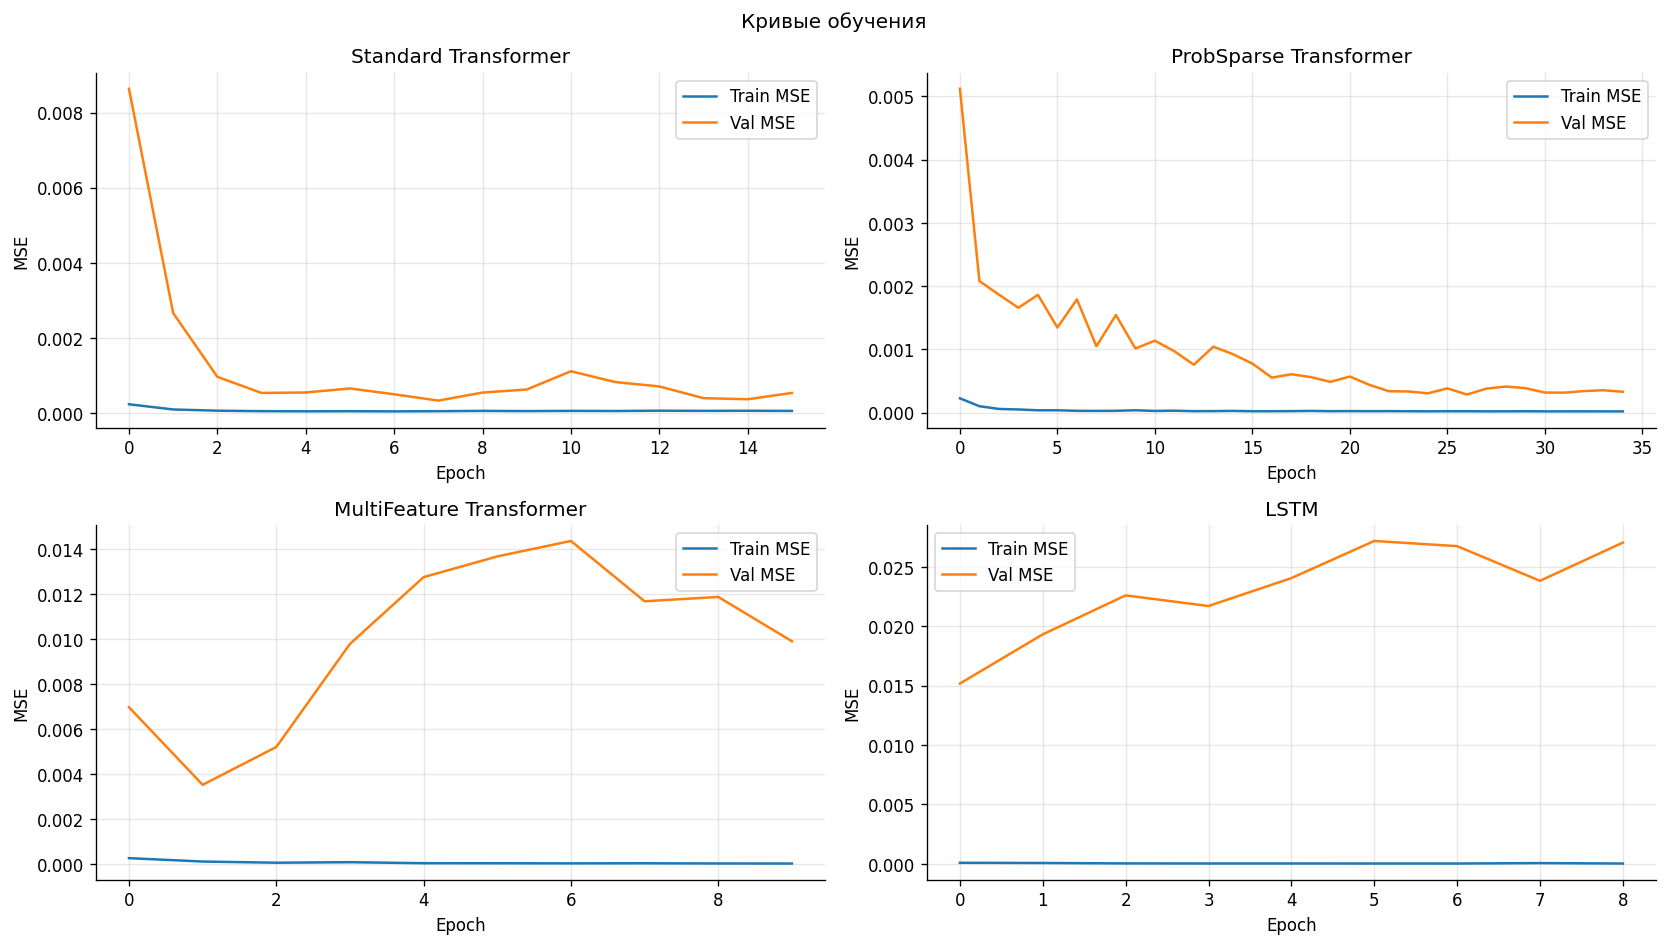

In [23]:
std_transformer   = standard_transformer
prob_transformer  = probsparse_transformer
multi_transformer = multifeature_transformer

fig, axes = plt.subplots(2, 2, figsize=(14,8))
for ax,(name,h) in zip(axes.ravel(), [
    ("Standard Transformer",    hist_std),
    ("ProbSparse Transformer",  hist_prob),
    ("MultiFeature Transformer",hist_multi),
    ("LSTM",                    hist_lstm)]):
    ax.plot(h["train"], label="Train MSE", linewidth=1.5)
    ax.plot(h["val"],   label="Val MSE",   linewidth=1.5)
    ax.set_title(name); ax.set_xlabel("Epoch"); ax.set_ylabel("MSE"); ax.legend()
plt.suptitle("Кривые обучения"); plt.tight_layout(); plt.show()


---
## 7. Классические модели

In [24]:
def extract_window_features(X_seq):
    return np.concatenate([
        X_seq[:,-1,:],
        X_seq.mean(axis=1),
        X_seq.std(axis=1),
        X_seq[:,-1,:] - X_seq[:,0,:]], axis=1)

X_train_cl = extract_window_features(X_train)
X_test_cl  = extract_window_features(X_test)
print(f"Матрица для классических моделей: {X_train_cl.shape}")

rng   = np.random.RandomState(SEED)
idx   = rng.choice(len(X_train_cl), min(CLASSICAL_SUB, len(X_train_cl)), replace=False)
X_sub, y_sub = X_train_cl[idx], y_train[idx]

print("\nОбучение Random Forest...")
t0 = time.time()
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10,
    min_samples_leaf=5, max_features=0.5, n_jobs=-1, random_state=SEED)
rf_model.fit(X_sub, y_sub)
print(f"  Готово за {time.time()-t0:.1f}с")

print("\nОбучение XGBoost...")
t0 = time.time()
xgb_model = XGBRegressor(n_estimators=500, learning_rate=0.03, max_depth=5,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    reg_alpha=0.1, reg_lambda=1.0, tree_method="hist",
    random_state=SEED, verbosity=0)
xgb_model.fit(X_sub, y_sub, eval_set=[(X_test_cl, y_test)], verbose=False)
print(f"  Готово за {time.time()-t0:.1f}с")


Матрица для классических моделей: (112415, 96)

Обучение Random Forest...
  Готово за 9.3с

Обучение XGBoost...
  Готово за 3.6с


In [25]:
def fracdiff_weights(d, size, thresh=1e-5):
    w = [1.0]
    for k in range(1, size):
        w.append(-w[-1]*(d-k+1)/k)
    return np.array([x for x in w if abs(x) > thresh])

def fractional_diff(series, d):
    w = fracdiff_weights(d, len(series))
    width = len(w)
    return np.array([np.dot(w[::-1], series[i-width:i])
                     for i in range(width, len(series))])

def arfima_rolling_predict(train_series, test_series, d=ARFIMA_D,
                            p=1, q=1, retrain_every=500):
    train_lr = np.log(train_series[1:] / train_series[:-1])
    test_lr  = np.log(test_series[1:]  / test_series[:-1])
    full_lr  = np.concatenate([train_lr, test_lr])
    n_train  = len(train_lr)
    preds, last_price, fit = [], train_series[-1], None

    for i in range(len(test_lr)):
        if i % retrain_every == 0:
            hist = full_lr[:n_train+i]
            try:
                diff_h = fractional_diff(hist, d)
                if len(diff_h) < max(p,q)+20: diff_h = hist
                fit = ARIMA(diff_h, order=(p,0,q),
                            enforce_stationarity=False,
                            enforce_invertibility=False).fit(method="css-mle")
            except: fit = None
        pred_lr = np.clip(float(fit.forecast(1).iloc[0]), -0.05, 0.05) if fit else 0.0
        pred_p  = last_price * np.exp(pred_lr)
        preds.append(pred_p)
        last_price = test_series[i]
    return np.array(preds)

print("Обучение ARFIMA (~2-3 мин)...")
t0 = time.time()
pred_arfima_raw = arfima_rolling_predict(
    close_train_raw, close_test_raw, d=ARFIMA_D, p=1, q=1, retrain_every=500)
n_arfima_raw = len(pred_arfima_raw)
print(f"  Готово ({time.time()-t0:.1f}с), прогнозов: {n_arfima_raw}")
print(f"  Реальные: [{close_test_raw[:n_arfima_raw].min():.2f}, {close_test_raw[:n_arfima_raw].max():.2f}]")
print(f"  ARFIMA:   [{pred_arfima_raw.min():.2f}, {pred_arfima_raw.max():.2f}]")


Обучение ARFIMA (~2-3 мин)...
  Готово (43.9с), прогнозов: 48203
  Реальные: [208.06, 304.48]
  ARFIMA:   [208.06, 304.48]


---
## 8. Результаты: прогнозы и метрики

In [26]:
pred_std_sc   = predict_torch(std_transformer,   X_test)
pred_prob_sc  = predict_torch(prob_transformer,  X_test)
pred_multi_sc = predict_torch(multi_transformer, X_test)
pred_lstm_sc  = predict_torch(lstm,        X_test)

y_true        = inv_target(y_test)
pred_std      = inv_target(pred_std_sc)
pred_prob     = inv_target(pred_prob_sc)
pred_multi    = inv_target(pred_multi_sc)
pred_lstm     = inv_target(pred_lstm_sc)

pred_xgb_sc   = xgb_model.predict(X_test_cl)
pred_rf_sc    = rf_model.predict(X_test_cl)
pred_xgb      = inv_target(pred_xgb_sc)
pred_rf       = inv_target(pred_rf_sc)

# ARFIMA: сдвиг из-за make_sequences
_arfima = pred_arfima_raw[INPUT_WINDOW:] if len(pred_arfima_raw)>INPUT_WINDOW else pred_arfima_raw
n_arfima = min(len(y_true), len(_arfima))
pred_arfima = _arfima[:n_arfima]

print("Диапазоны прогнозов:")
for nm, p in [("y_true",y_true),("Standard",pred_std),("ProbSparse",pred_prob),
              ("MultiFeature",pred_multi),("LSTM",pred_lstm),
              ("XGBoost",pred_xgb),("RF",pred_rf),("ARFIMA",pred_arfima)]:
    print(f"  {nm:<14}: [{np.array(p).min():.1f}, {np.array(p).max():.1f}]")


Диапазоны прогнозов:
  y_true        : [208.1, 304.5]
  Standard      : [207.5, 309.3]
  ProbSparse    : [208.7, 314.6]
  MultiFeature  : [192.8, 299.5]
  LSTM          : [203.3, 273.7]
  XGBoost       : [208.3, 238.2]
  RF            : [208.8, 239.3]
  ARFIMA        : [208.1, 304.5]


In [27]:
def compute_metrics(y_true, y_pred, name):
    yt = np.array(y_true).flatten()
    yp = np.array(y_pred).flatten()
    n  = min(len(yt), len(yp))
    yt, yp = yt[:n], yp[:n]

    mae   = mean_absolute_error(yt, yp)
    rmse  = np.sqrt(mean_squared_error(yt, yp))
    r2    = r2_score(yt, yp)
    mape  = np.mean(np.abs((yt-yp)/(np.abs(yt)+1e-8)))*100
    smape = np.mean(2*np.abs(yt-yp)/(np.abs(yt)+np.abs(yp)+1e-8))*100
    bias  = np.mean(yp - yt)
    max_e = np.max(np.abs(yt-yp))

    # направленная точность: % правильных предсказаний знака изменения
    da = np.mean(np.sign(np.diff(yt)) == np.sign(np.diff(yp))) * 100

    # коэффициент Тейла U2 (относительно наивного прогноза yt[t-1])
    naive_rmse = np.sqrt(np.mean((yt[1:]-yt[:-1])**2))
    theil_u2   = rmse / (naive_rmse + 1e-8)

    # автокорреляция остатков (лаг 1) — есть ли систематика в ошибках
    err   = yt - yp
    if len(err) > 2:
        acf1 = np.corrcoef(err[:-1], err[1:])[0,1]
    else:
        acf1 = np.nan

    return {"Модель": name, "MAE": mae, "RMSE": rmse, "R²": r2,
            "MAPE,%": mape, "sMAPE,%": smape, "Bias": bias,
            "MaxErr": max_e, "DirAcc,%": da,
            "TheilU2": theil_u2, "ACF1_err": acf1}

results = pd.DataFrame([
    compute_metrics(y_true, pred_std,   "Standard Transformer"),
    compute_metrics(y_true, pred_prob,  "ProbSparse Transformer"),
    compute_metrics(y_true, pred_multi, "MultiFeature Transformer"),
    compute_metrics(y_true, pred_lstm,  "LSTM"),
    compute_metrics(y_true, pred_xgb,   "XGBoost"),
    compute_metrics(y_true, pred_rf,    "Random Forest"),
    compute_metrics(y_true[:n_arfima], pred_arfima, "ARFIMA"),
]).sort_values("R²", ascending=False).reset_index(drop=True)

for col in ["MAE","RMSE","MAPE,%","sMAPE,%","Bias","MaxErr","TheilU2","ACF1_err"]:
    results[col] = results[col].round(4)
results["R²"]       = results["R²"].round(5)
results["DirAcc,%"] = results["DirAcc,%"].round(2)

print("=== Метрики качества прогнозирования ===\n")
display(results)
print("\nDirAcc — направленная точность (%), TheilU2 < 1 лучше наивного, ACF1_err — автокорреляция остатков")


=== Метрики качества прогнозирования ===



,Модель,MAE,RMSE,R²,"MAPE,%","sMAPE,%",Bias,MaxErr,"DirAcc,%",TheilU2,ACF1_err
0,ARFIMA,0.3582,0.7869,0.99841,0.1382,0.1382,-0.0010,22.5000,42.67,1.0000,-0.2983
1,ProbSparse Transformer,1.0649,1.7456,0.99217,0.3898,0.3884,0.7352,22.7918,53.22,2.2182,0.7026
2,Standard Transformer,1.1729,1.8653,0.99106,0.4394,0.4384,0.9197,47.2601,47.50,2.3704,0.5471
3,MultiFeature Transformer,3.9954,6.1364,0.90325,1.4707,1.4946,-3.3764,92.8540,47.82,7.7980,0.7940
4,LSTM,9.4620,12.7159,0.58454,3.4565,3.5631,-9.3810,63.0782,49.69,16.1590,0.9853
5,Random Forest,21.1829,27.3994,-0.92891,7.7334,8.2531,-21.1030,65.2845,50.86,34.8184,0.9989
6,XGBoost,23.7317,29.8466,-1.28886,8.6992,9.3227,-23.6267,67.4426,54.30,37.9282,0.9989



DirAcc — направленная точность (%), TheilU2 < 1 лучше наивного, ACF1_err — автокорреляция остатков


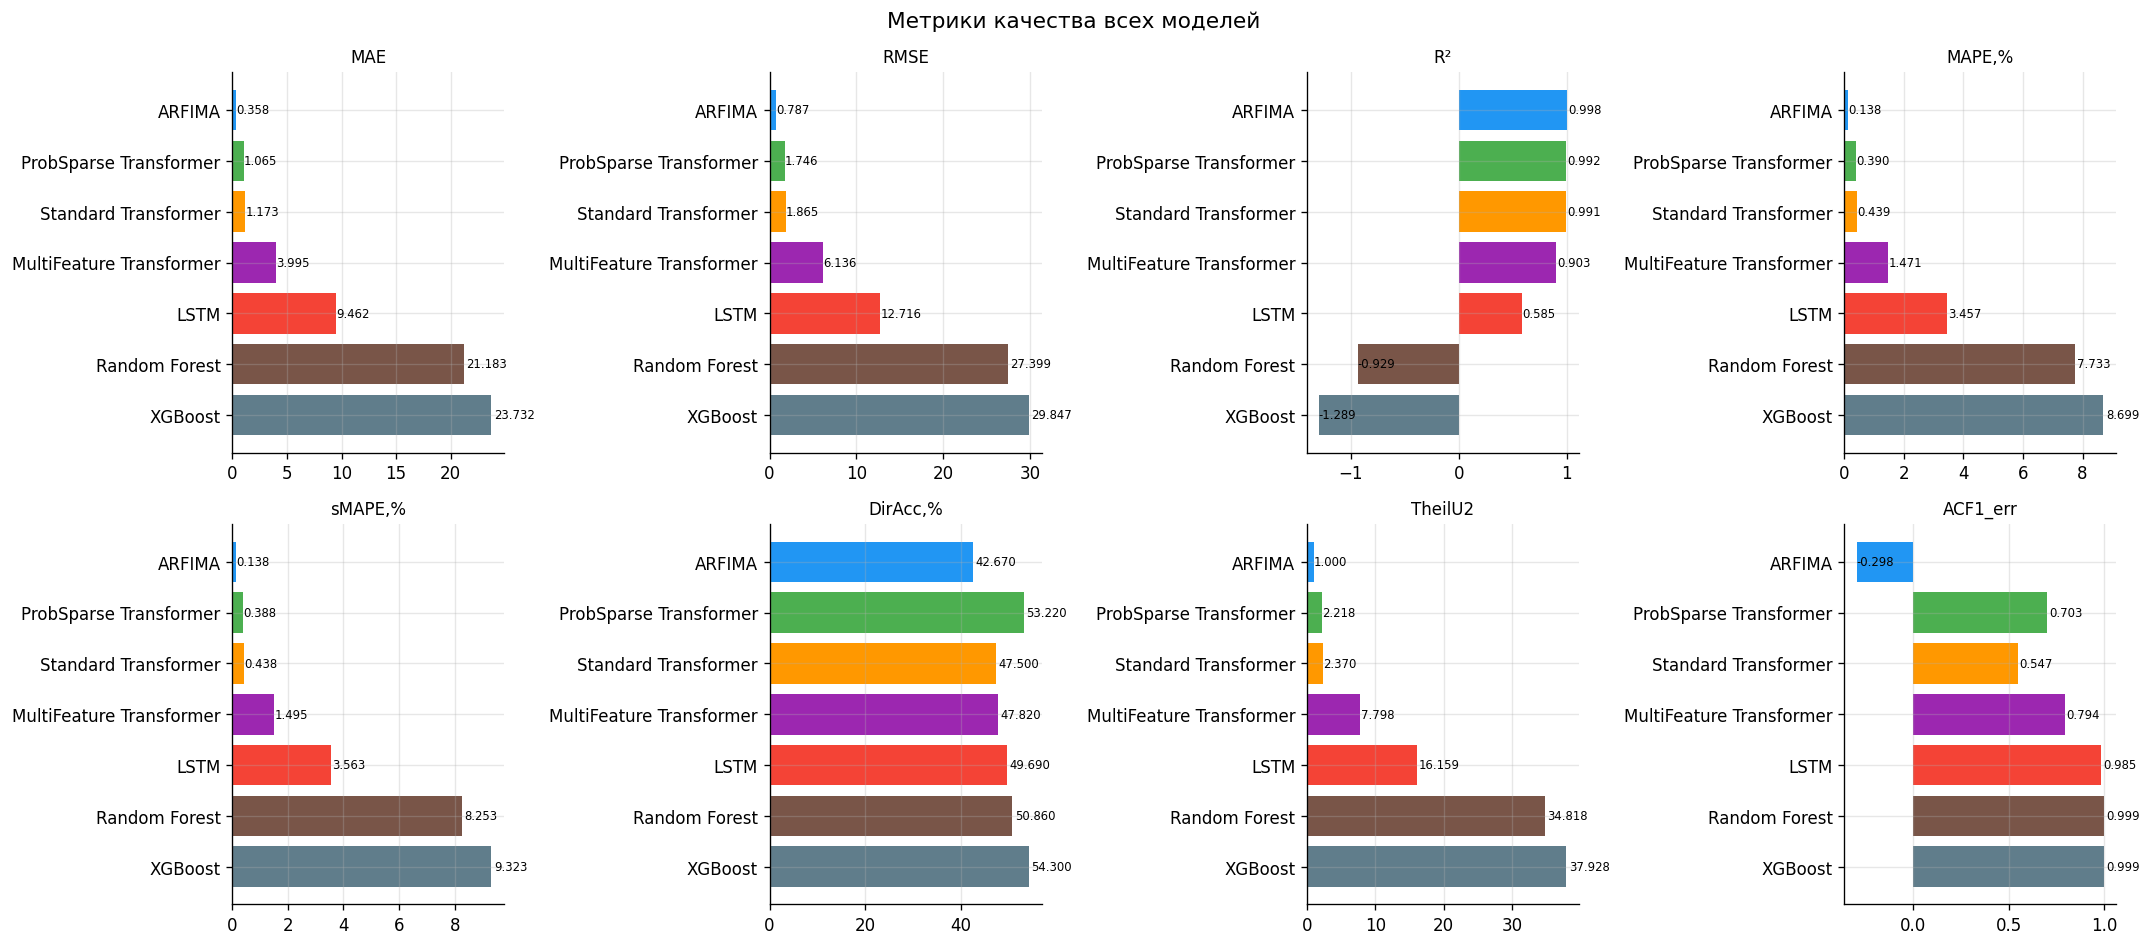

In [28]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
metrics = ["MAE","RMSE","R²","MAPE,%","sMAPE,%","DirAcc,%","TheilU2","ACF1_err"]
colors  = ["#2196F3","#4CAF50","#FF9800","#9C27B0","#F44336","#795548","#607D8B"]
for ax, metric in zip(axes.ravel(), metrics):
    vals  = results[metric].values
    names = results["Модель"].tolist()
    bars  = ax.barh(names, vals, color=colors)
    ax.set_title(metric, fontsize=10); ax.invert_yaxis()
    for bar, val in zip(bars, vals):
        ax.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
                f"{val:.3f}", va="center", fontsize=7)
plt.suptitle("Метрики качества всех моделей", fontsize=13)
plt.tight_layout(); plt.show()


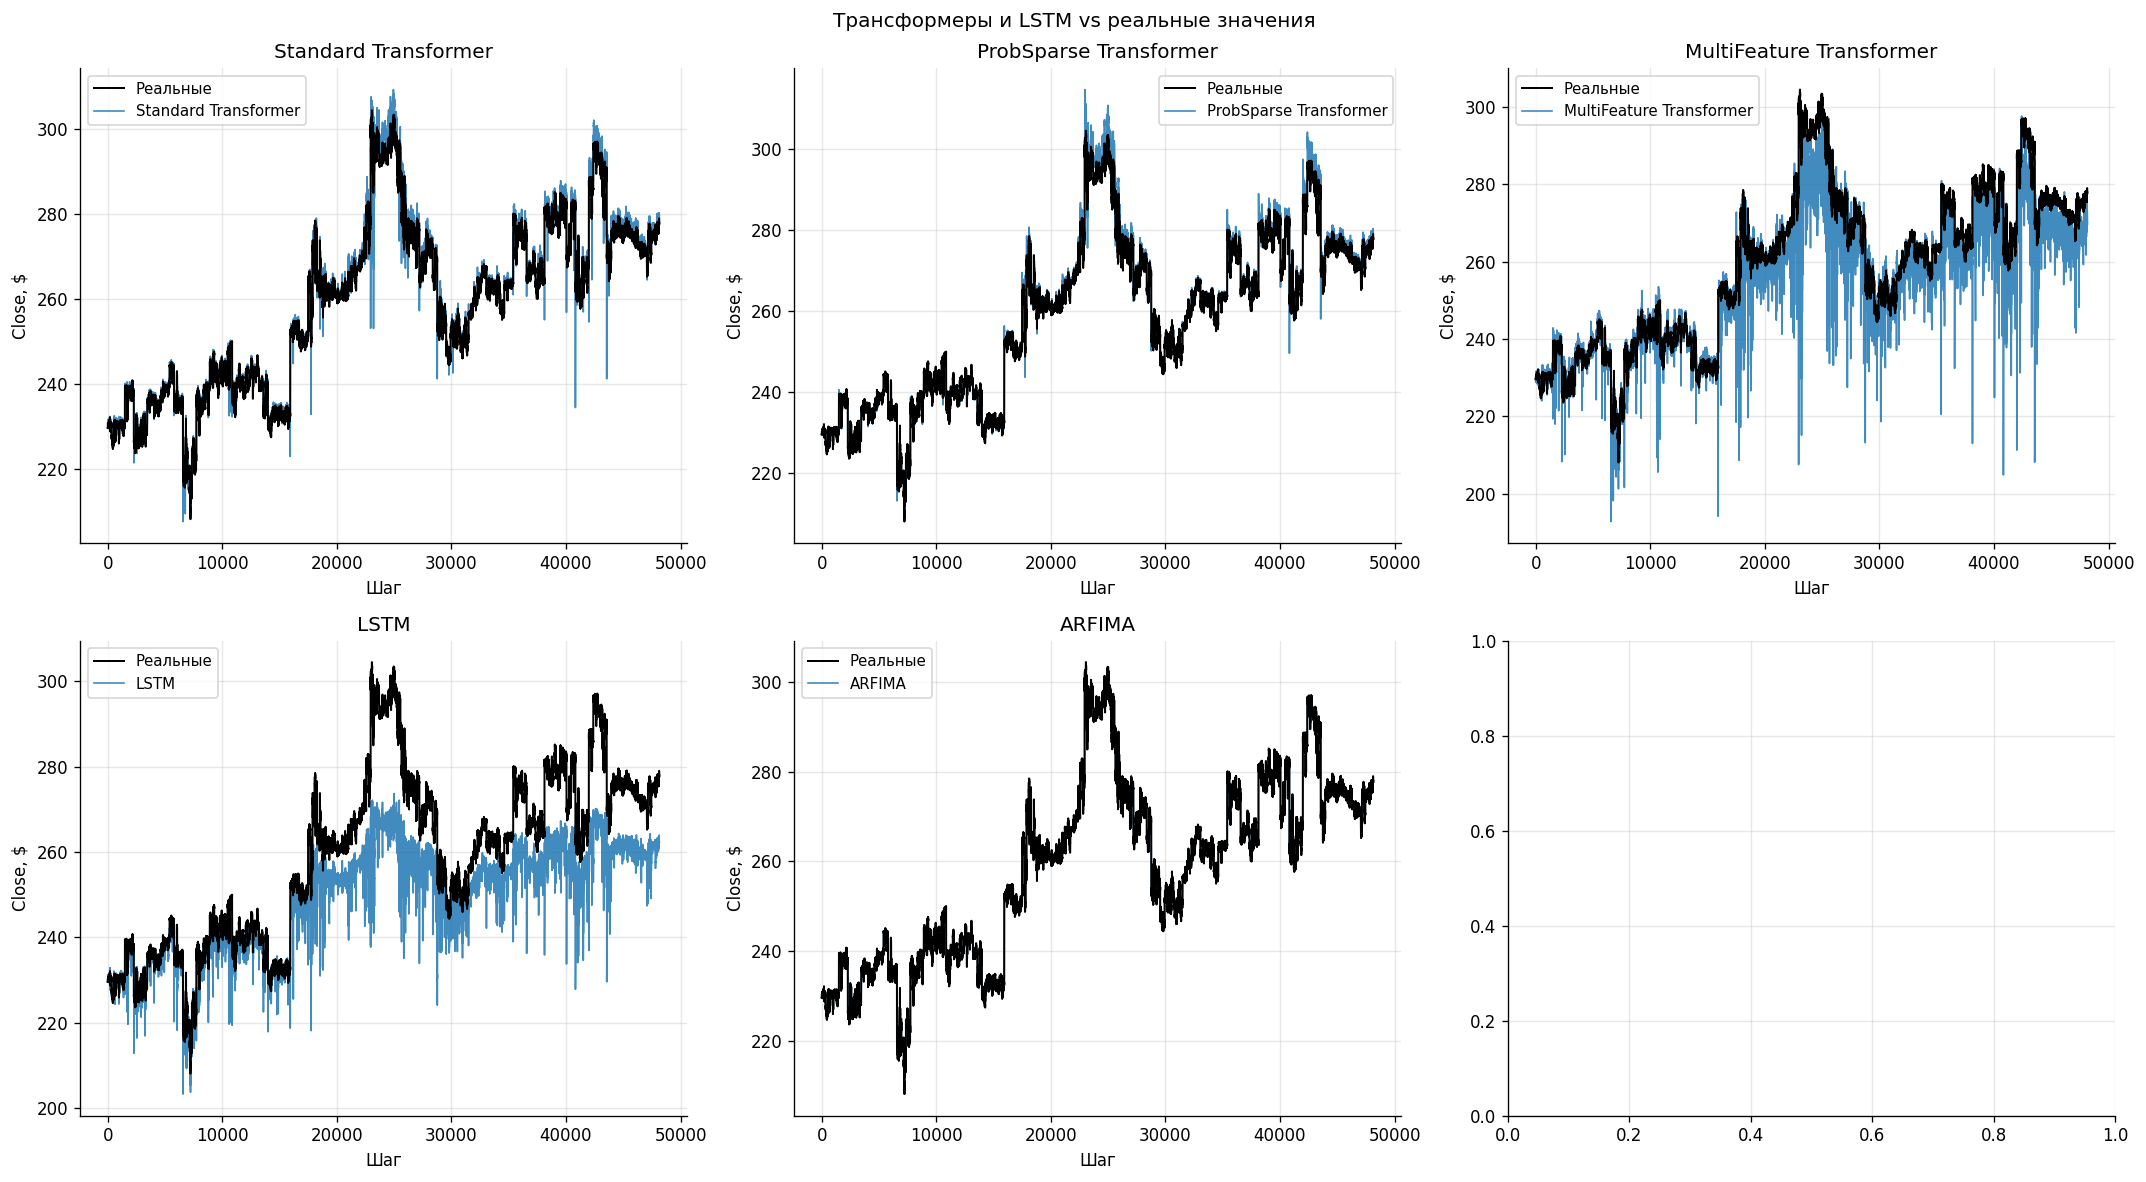

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, (name, pred) in zip(axes.ravel(), [
    ("Standard Transformer",    pred_std),
    ("ProbSparse Transformer",  pred_prob),
    ("MultiFeature Transformer",pred_multi),
    ("LSTM",                    pred_lstm),
    ("ARFIMA", pred_arfima)]):
    ax.plot(y_true, color="black", linewidth=1.2, label="Реальные", zorder=3)
    ax.plot(pred,   linewidth=1.0, label=name, alpha=0.85)
    ax.set_title(name); ax.set_xlabel("Шаг"); ax.set_ylabel("Close, $"); ax.legend(fontsize=9)
plt.suptitle("Трансформеры и LSTM vs реальные значения"); plt.tight_layout(); plt.show()


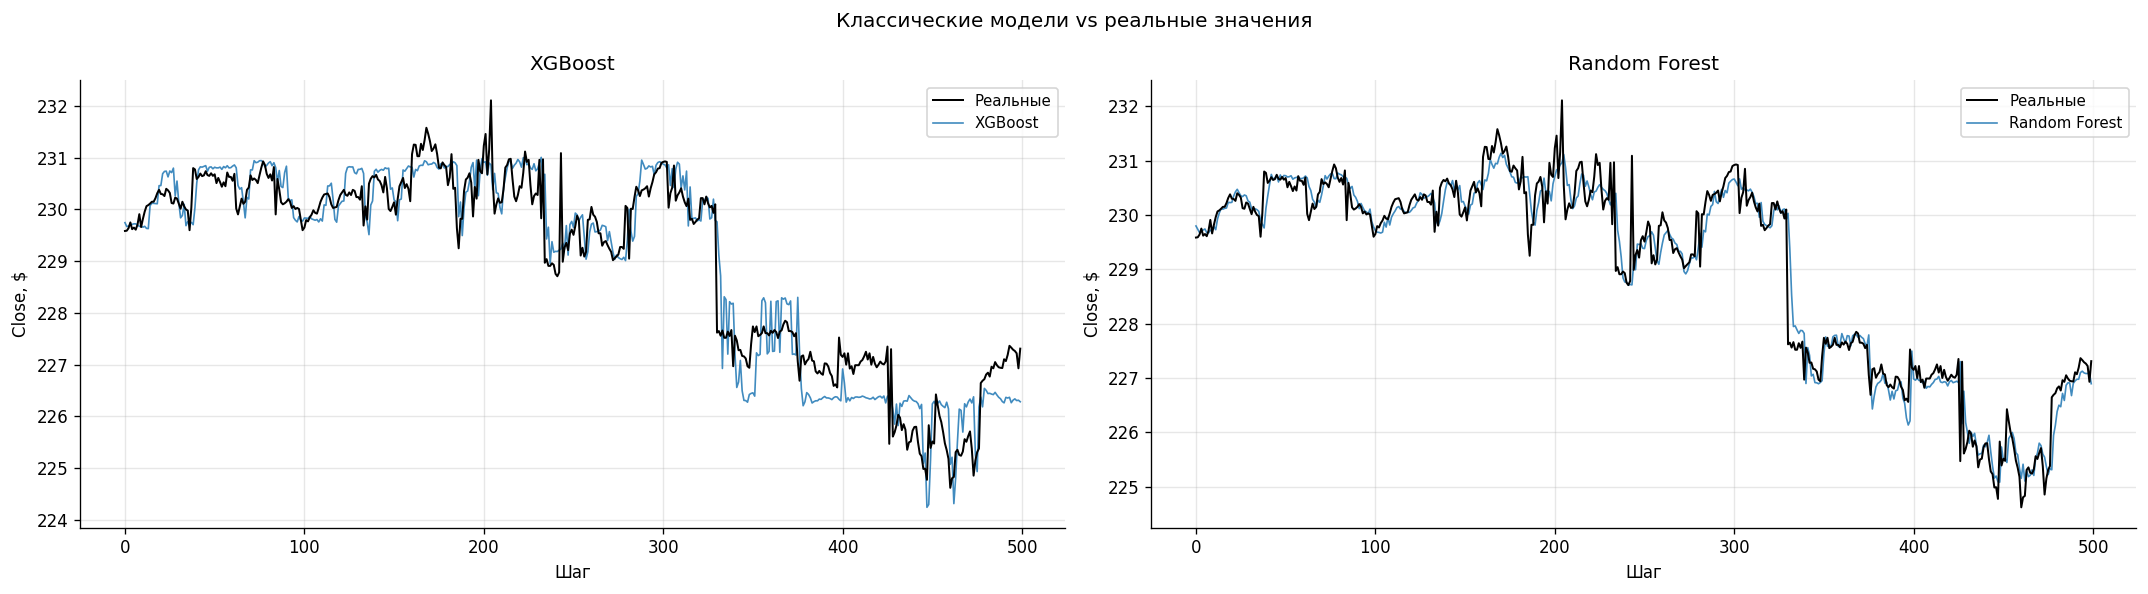

In [30]:
N = N_PLOT
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
for ax, (name, pred) in zip(axes, [
    ("XGBoost", pred_xgb), ("Random Forest", pred_rf)]):
    ax.plot(y_true[:N], color="black", linewidth=1.2, label="Реальные", zorder=3)
    ax.plot(pred[:N],   linewidth=1.0, label=name, alpha=0.85)
    ax.set_title(name); ax.set_xlabel("Шаг"); ax.set_ylabel("Close, $"); ax.legend(fontsize=9)
plt.suptitle("Классические модели vs реальные значения"); plt.tight_layout(); plt.show()


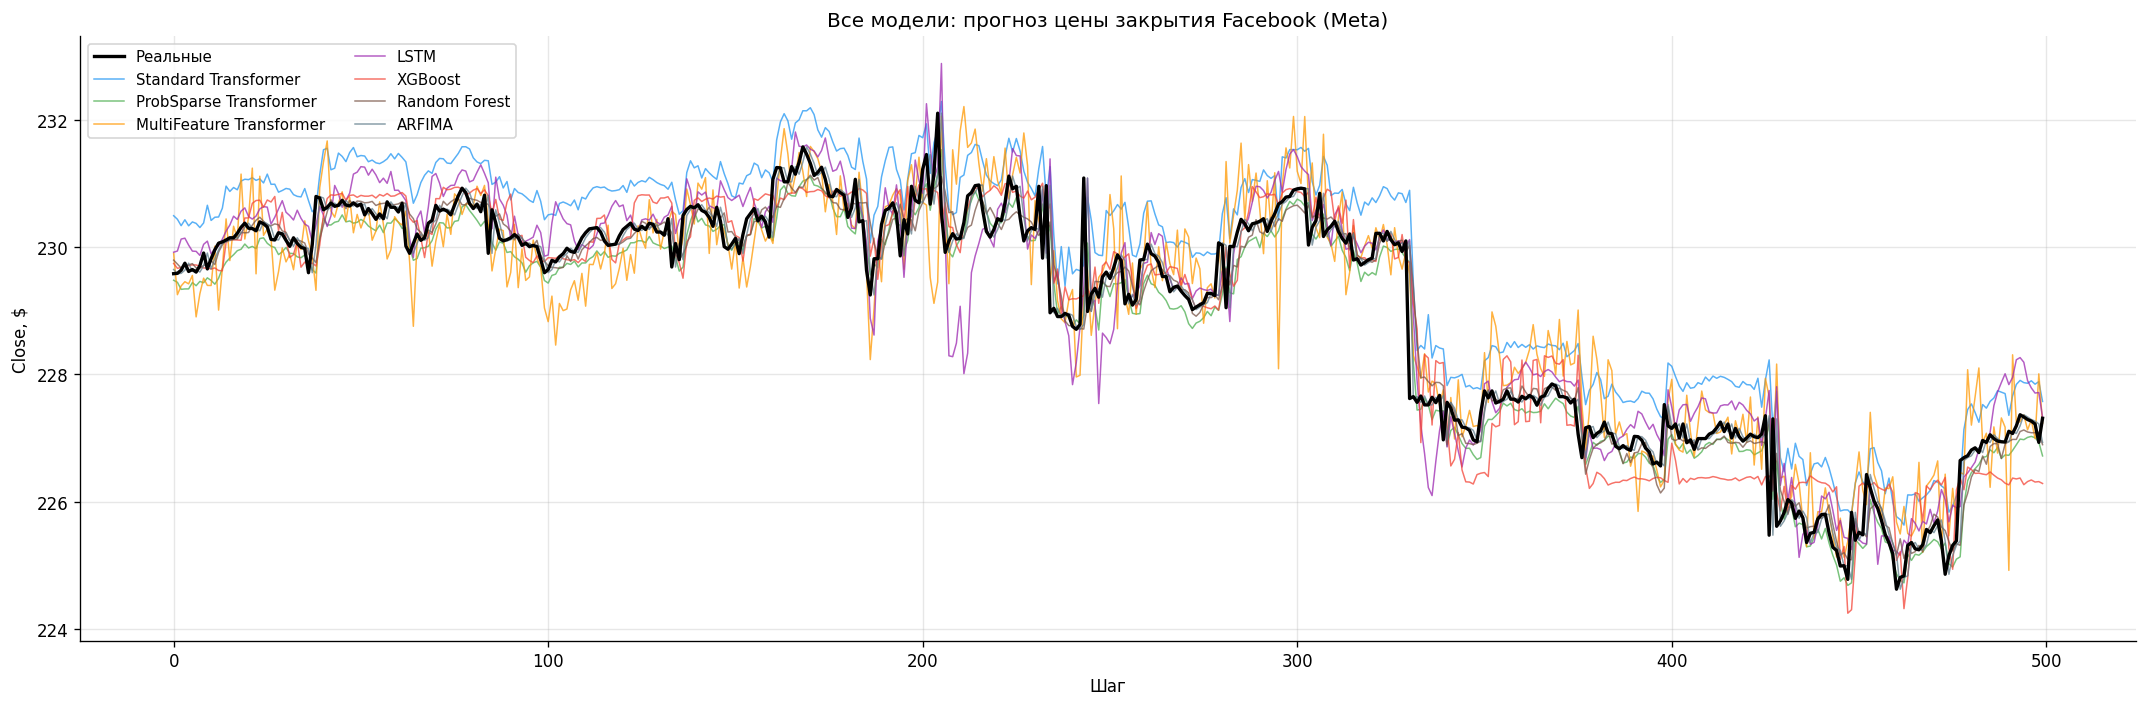

In [31]:
N = N_PLOT
palette = {"Standard Transformer":"#2196F3","ProbSparse Transformer":"#4CAF50",
           "MultiFeature Transformer":"#FF9800","LSTM":"#9C27B0",
           "XGBoost":"#F44336","Random Forest":"#795548","ARFIMA":"#607D8B"}
fig, ax = plt.subplots(figsize=(18, 6))
ax.plot(y_true[:N], color="black", linewidth=2, label="Реальные", zorder=5)
for name, pred in [("Standard Transformer",pred_std),("ProbSparse Transformer",pred_prob),
                   ("MultiFeature Transformer",pred_multi),("LSTM",pred_lstm),
                   ("XGBoost",pred_xgb),("Random Forest",pred_rf),("ARFIMA",pred_arfima)]:
    ax.plot(pred[:N], label=name, color=palette[name], linewidth=0.9, alpha=0.75)
ax.set_title("Все модели: прогноз цены закрытия Facebook (Meta)")
ax.set_xlabel("Шаг"); ax.set_ylabel("Close, $")
ax.legend(loc="upper left", fontsize=9, ncol=2)
plt.tight_layout(); plt.show()


---
## 9. Расширенная аналитика прогнозов

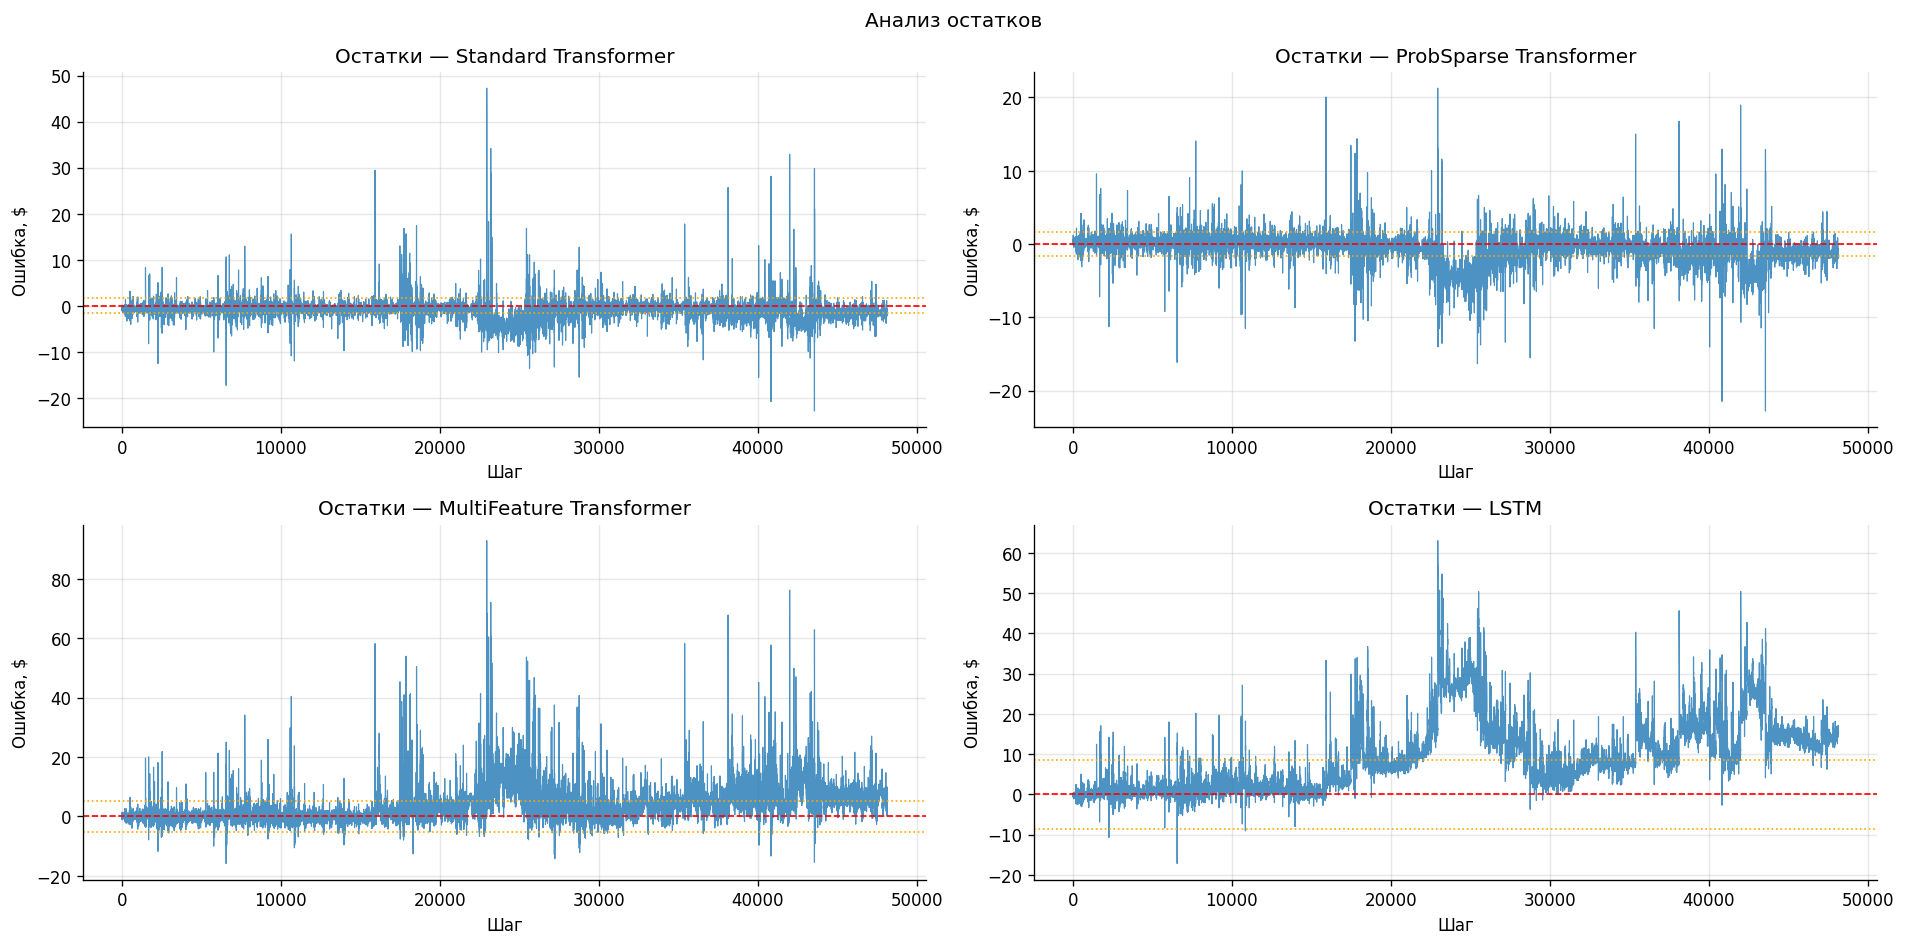

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
for ax, (name, pred) in zip(axes.ravel(), [
    ("Standard Transformer",pred_std),("ProbSparse Transformer",pred_prob),
    ("MultiFeature Transformer",pred_multi),("LSTM",pred_lstm), ("ARFIMA", pred_arfima)]):
    err = y_true - np.array(pred)
    ax.plot(err, linewidth=0.7, alpha=0.8)
    ax.axhline(0,       color="red",    linewidth=1, linestyle="--")
    ax.axhline( err.std(), color="orange", linewidth=1, linestyle=":")
    ax.axhline(-err.std(), color="orange", linewidth=1, linestyle=":")
    ax.set_title(f"Остатки — {name}")
    ax.set_xlabel("Шаг"); ax.set_ylabel("Ошибка, $")
plt.suptitle("Анализ остатков"); plt.tight_layout(); plt.show()


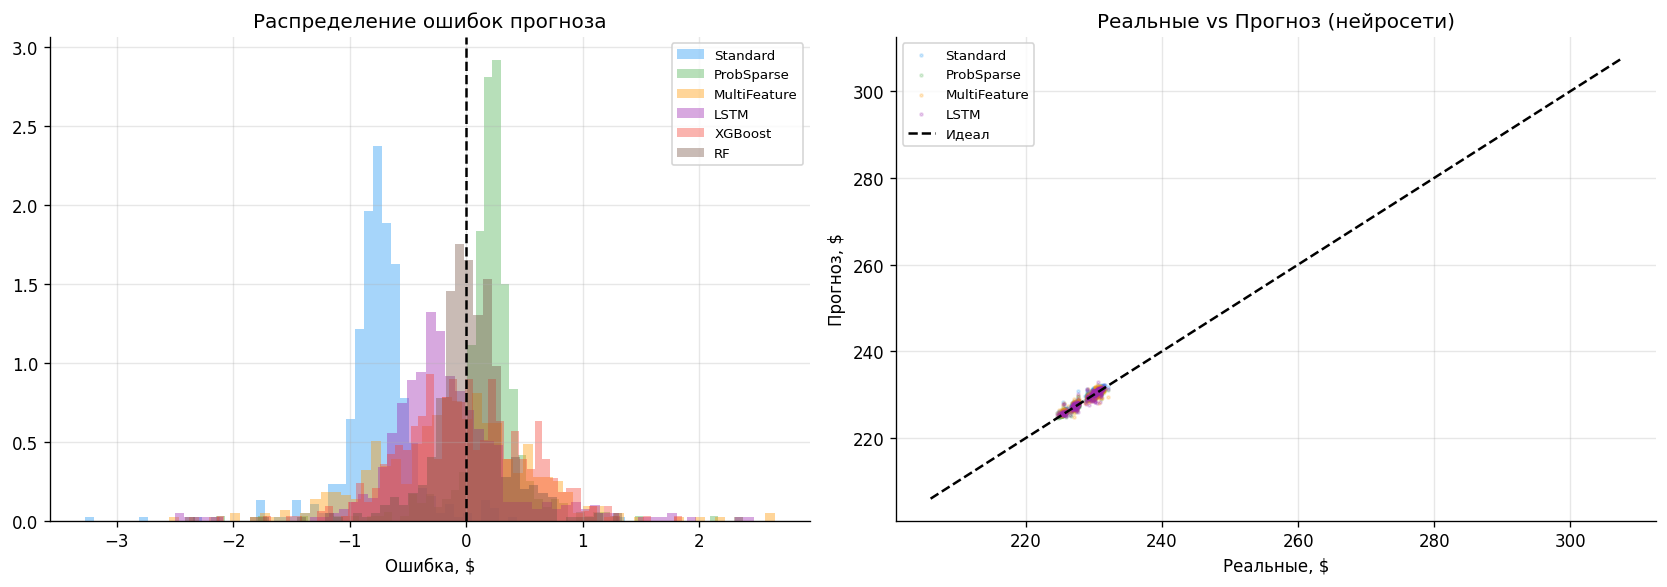

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── распределение ошибок ──────────────────────────────────────────────
for name, pred, col in [
    ("Standard",    pred_std,   "#2196F3"),
    ("ProbSparse",  pred_prob,  "#4CAF50"),
    ("MultiFeature",pred_multi, "#FF9800"),
    ("LSTM",        pred_lstm,  "#9C27B0"),
    ("XGBoost",     pred_xgb,   "#F44336"),
    ("RF",          pred_rf,    "#795548")]:
    err = y_true[:N_PLOT] - np.array(pred)[:N_PLOT]
    axes[0].hist(err, bins=60, alpha=0.4, label=name, color=col, density=True)
axes[0].axvline(0, color="black", linewidth=1.5, linestyle="--")
axes[0].set_title("Распределение ошибок прогноза")
axes[0].set_xlabel("Ошибка, $"); axes[0].legend(fontsize=8)

# ── scatter: реальные vs прогноз ──────────────────────────────────────
for name, pred, col in [
    ("Standard",    pred_std,   "#2196F3"),
    ("ProbSparse",  pred_prob,  "#4CAF50"),
    ("MultiFeature",pred_multi, "#FF9800"),
    ("LSTM",        pred_lstm,  "#9C27B0")]:
    axes[1].scatter(y_true[:N_PLOT], np.array(pred)[:N_PLOT],
                    alpha=0.2, s=3, label=name, color=col)
lim_lo = y_true.min()*0.99; lim_hi = y_true.max()*1.01
axes[1].plot([lim_lo,lim_hi],[lim_lo,lim_hi],"k--",linewidth=1.5,label="Идеал")
axes[1].set_title("Реальные vs Прогноз (нейросети)")
axes[1].set_xlabel("Реальные, $"); axes[1].set_ylabel("Прогноз, $")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


In [34]:
# ── направленная точность по волатильным и спокойным периодам ─────────
vol = pd.Series(y_true).rolling(20).std().values
high_vol_mask = vol > np.nanpercentile(vol, 75)
low_vol_mask  = vol < np.nanpercentile(vol, 25)

rows_da = []
for name, pred in [("Standard",pred_std),("ProbSparse",pred_prob),
                   ("MultiFeature",pred_multi),("LSTM",pred_lstm),
                   ("XGBoost",pred_xgb),("RF",pred_rf)]:
    yt = y_true; yp = np.array(pred)
    n  = min(len(yt), len(yp))
    yt, yp = yt[:n], yp[:n]
    sign_true = np.sign(np.diff(yt))
    sign_pred = np.sign(np.diff(yp))
    da_all  = np.mean(sign_true == sign_pred)*100
    m_hv = high_vol_mask[1:n]
    m_lv = low_vol_mask[1:n]
    da_hv = np.mean(sign_true[m_hv] == sign_pred[m_hv])*100 if m_hv.sum()>0 else np.nan
    da_lv = np.mean(sign_true[m_lv] == sign_pred[m_lv])*100 if m_lv.sum()>0 else np.nan
    rows_da.append({"Модель":name, "DA всего,%":round(da_all,2),
                    "DA высокая волат.,%":round(da_hv,2),
                    "DA низкая волат.,%":round(da_lv,2)})

da_df = pd.DataFrame(rows_da)
print("=== Направленная точность по режимам волатильности ===\n")
display(da_df)


=== Направленная точность по режимам волатильности ===



,Модель,"DA всего,%","DA высокая волат.,%","DA низкая волат.,%"
0,Standard,47.50,48.27,46.36
1,ProbSparse,53.22,54.63,50.84
2,MultiFeature,47.82,49.55,46.75
3,LSTM,49.69,49.71,49.37
4,XGBoost,54.30,56.35,53.01
5,RF,50.86,52.97,48.51


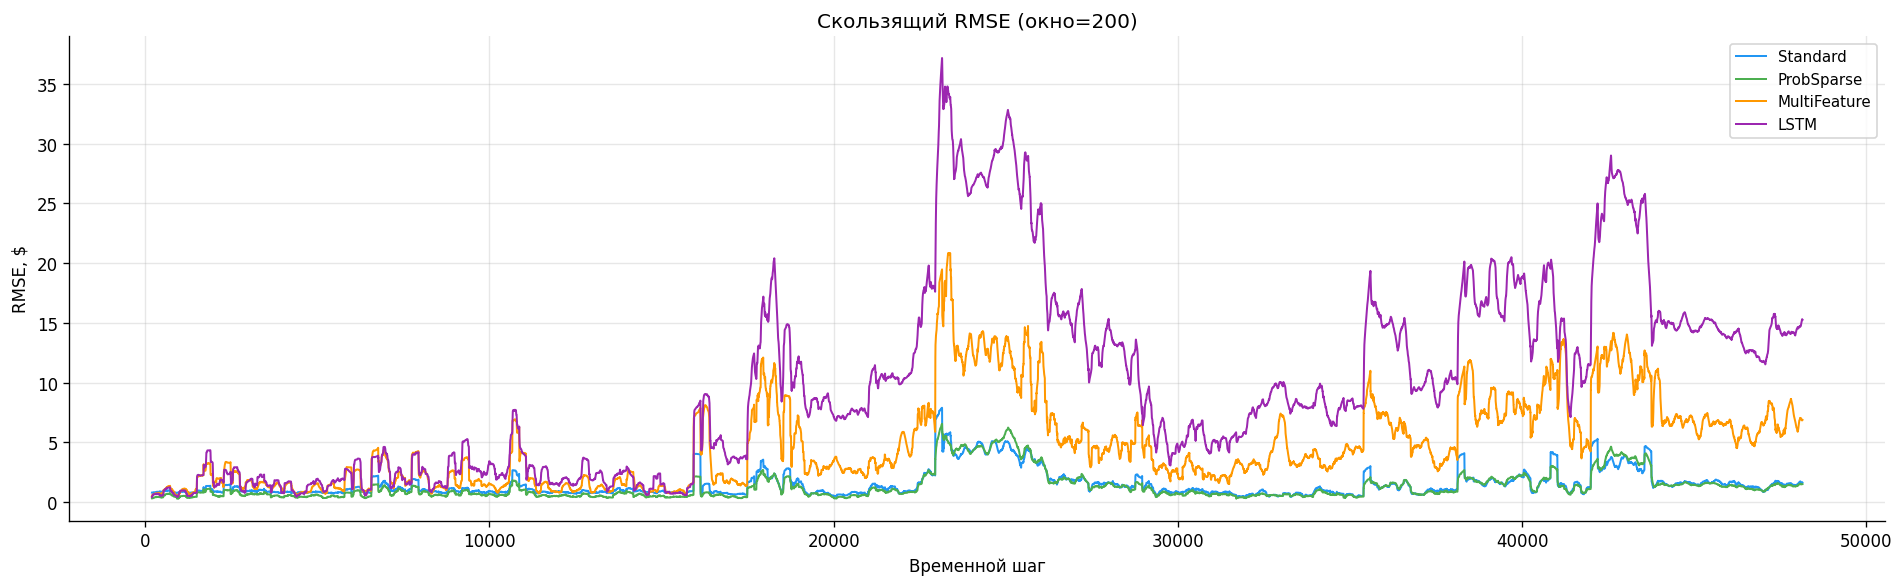

In [35]:
# ── скользящий RMSE: как ошибка меняется во времени ───────────────────
window_rmse = 200
fig, ax = plt.subplots(figsize=(16, 5))
for name, pred, col in [
    ("Standard",    pred_std,   "#2196F3"),
    ("ProbSparse",  pred_prob,  "#4CAF50"),
    ("MultiFeature",pred_multi, "#FF9800"),
    ("LSTM",        pred_lstm,  "#9C27B0")]:
    yp  = np.array(pred)[:len(y_true)]
    err2 = (y_true - yp)**2
    roll_rmse = pd.Series(err2).rolling(window_rmse).mean().apply(np.sqrt).values
    ax.plot(roll_rmse, label=name, color=col, linewidth=1.2)
ax.set_title(f"Скользящий RMSE (окно={window_rmse})")
ax.set_xlabel("Временной шаг"); ax.set_ylabel("RMSE, $")
ax.legend(fontsize=9); plt.tight_layout(); plt.show()


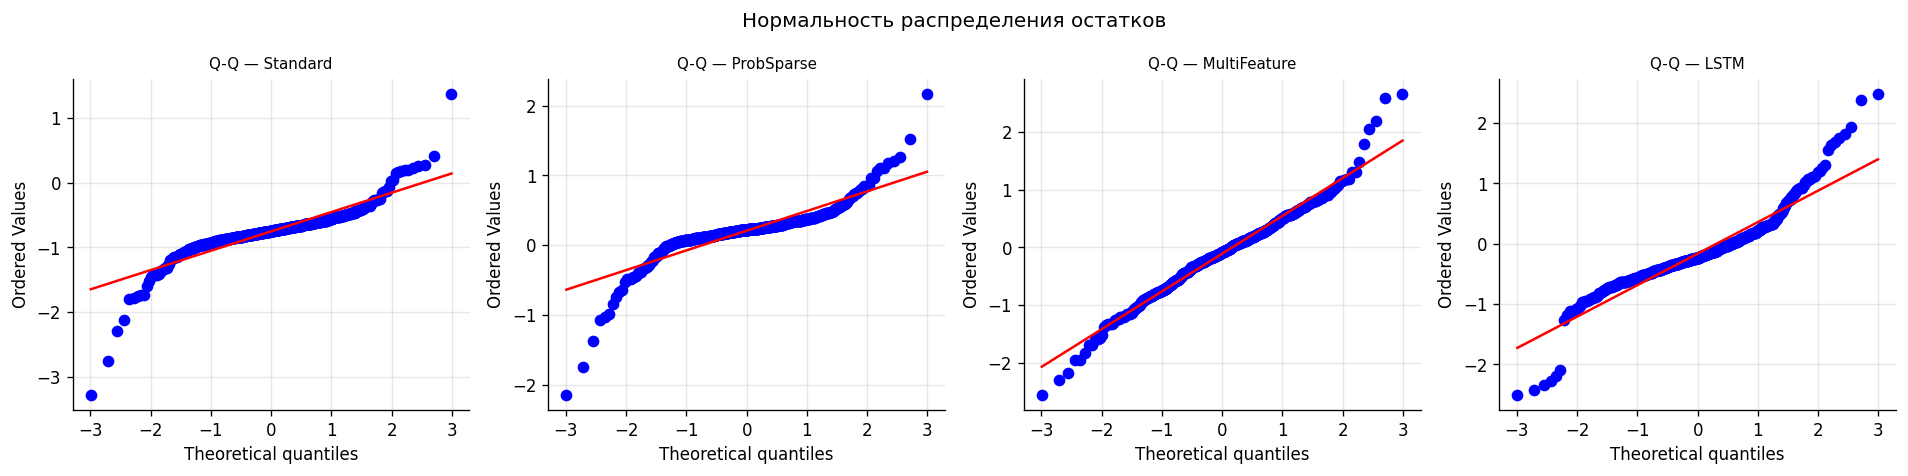

In [36]:
# ── Q-Q plot остатков (нормальность) ──────────────────────────────────
from scipy import stats as sp_stats
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, pred) in zip(axes, [
    ("Standard",    pred_std),
    ("ProbSparse",  pred_prob),
    ("MultiFeature",pred_multi),
    ("LSTM",        pred_lstm)]):
    err = y_true[:N_PLOT] - np.array(pred)[:N_PLOT]
    sp_stats.probplot(err, dist="norm", plot=ax)
    ax.set_title(f"Q-Q — {name}", fontsize=9)
plt.suptitle("Нормальность распределения остатков")
plt.tight_layout(); plt.show()


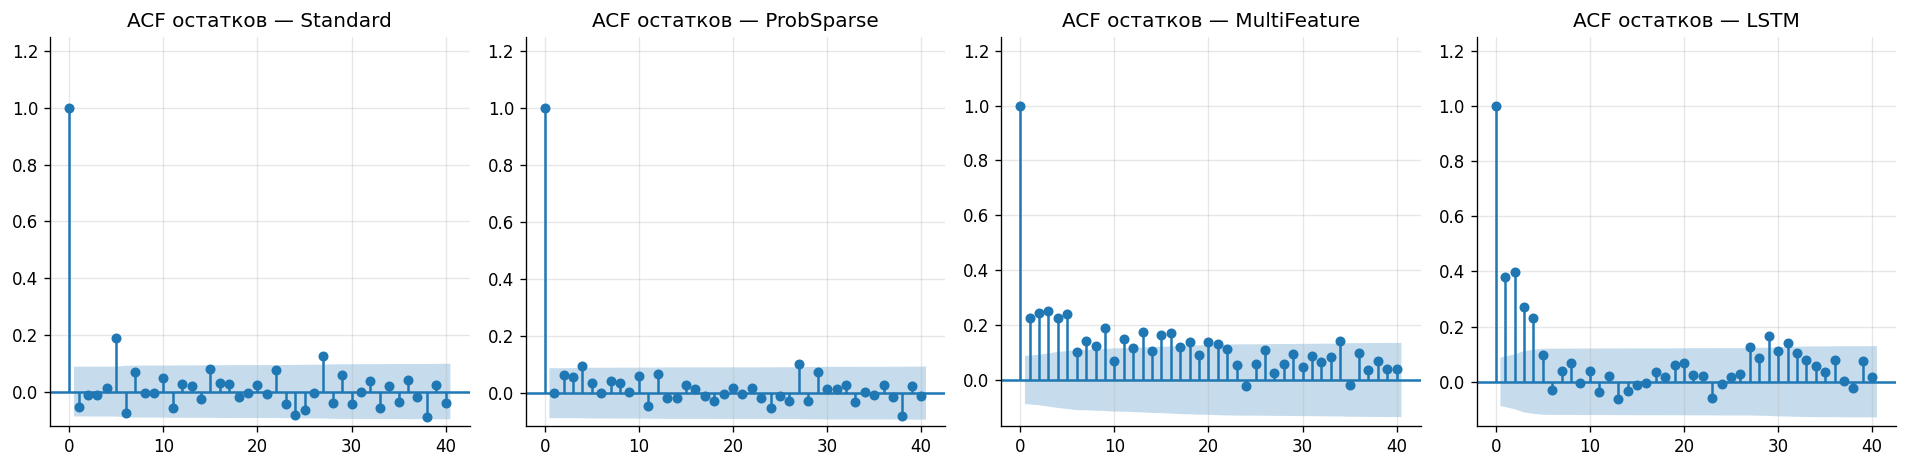

In [37]:
# ── ACF остатков ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, pred) in zip(axes, [
    ("Standard",pred_std),("ProbSparse",pred_prob),
    ("MultiFeature",pred_multi),("LSTM",pred_lstm)]):
    err = y_true[:N_PLOT] - np.array(pred)[:N_PLOT]
    plot_acf(err, lags=40, ax=ax, title=f"ACF остатков — {name}", auto_ylims=True)
plt.tight_layout(); plt.show()


---
## 10. Сохранение моделей

In [38]:
os.makedirs("saved_models", exist_ok=True)
for model, name in [(std_transformer,"std_transformer"),
                    (prob_transformer,"prob_transformer"),
                    (multi_transformer,"multi_transformer")]:
    torch.save({
        "model_state_dict": model.state_dict(),
        "model_class": type(model).__name__,
        "input_dim": len(features),
        "seq_len": INPUT_WINDOW,
        "features": features,
        "d_model": D_MODEL, "nhead": NHEAD,
        "num_layers": NUM_LAYERS, "dropout": DROPOUT,
    }, f"saved_models/{name}.pth")
    print(f"  Сохранено: saved_models/{name}.pth")

with open("saved_models/scalers.pkl", "wb") as f:
    pickle.dump({"feature_scalers": feature_scalers,
                 "target_scaler":   target_scaler,
                 "features":        features}, f)
print("  Скейлеры сохранены.")


  Сохранено: saved_models/std_transformer.pth
  Сохранено: saved_models/prob_transformer.pth
  Сохранено: saved_models/multi_transformer.pth
  Скейлеры сохранены.


---
## 11. Применение трансформеров: Boeing и JP Morgan

In [39]:
def preprocess_new_dataset(csv_path, feature_scalers, target_scaler, features):
    df_n = pd.read_csv(csv_path)
    df_n["date"] = pd.to_datetime(df_n["date"], errors="coerce")
    df_n = df_n.sort_values("date").reset_index(drop=True).set_index("date")
    for c in df_n.select_dtypes(include=[np.number]).columns:
        df_n[c] = df_n[c].replace([np.inf,-np.inf], np.nan).ffill().bfill()
    for col in ["high","low"]:
        if col in df_n.columns:
            df_n[col] = df_n[col].replace(0,np.nan).interpolate(method="time")
            df_n[col] = df_n[col].rolling(5,min_periods=1).mean()
    df_n["returns"]      = df_n["close"].pct_change()
    df_n["log_returns"]  = np.log(df_n["close"]/df_n["close"].shift(1))
    df_n["range_hl"]     = (df_n["high"]-df_n["low"])/df_n["close"]
    df_n["range_co"]     = (df_n["close"]-df_n["open"])/df_n["open"]
    df_n["volatility_20"]= df_n["returns"].rolling(20).std()
    df_n["ma_10"]        = df_n["close"].rolling(10).mean()
    df_n["ma_20"]        = df_n["close"].rolling(20).mean()
    df_n["ma_ratio"]     = df_n["ma_10"]/df_n["ma_20"]
    df_n["volume_ma_20"] = df_n["volume"].rolling(20).mean()
    df_n["volume_ratio"] = df_n["volume"]/df_n["volume_ma_20"]
    for lag in [1,2,3,5]:
        df_n[f"close_lag_{lag}"]   = df_n["close"].shift(lag)
        df_n[f"returns_lag_{lag}"] = df_n["returns"].shift(lag)
    df_n = df_n.replace([np.inf,-np.inf], np.nan).ffill().bfill()
    for f in features:
        if f not in df_n.columns: df_n[f] = 0.0
    sc_cols = []
    for col in features:
        sc = feature_scalers.get(col)
        vals = df_n[col].values.reshape(-1,1)
        sc_cols.append(sc.transform(vals).flatten() if sc else vals.flatten())
    X_mat = np.column_stack(sc_cols)
    y_raw = df_n["close"].values
    Xs, ys = [], []
    for i in range(len(X_mat)-INPUT_WINDOW):
        Xs.append(X_mat[i:i+INPUT_WINDOW]); ys.append(y_raw[i+INPUT_WINDOW])
    return np.array(Xs,dtype=np.float32), np.array(ys,dtype=np.float32)

def apply_model(model, X_seq, target_scaler):
    sc = predict_torch(model, X_seq)
    return target_scaler.inverse_transform(sc.reshape(-1,1)).flatten()


Boeing
Последовательностей: 158898


,Модель,MAE,RMSE,R²,"DirAcc,%",TheilU2
0,Standard Transformer,3.6859,5.8391,0.9963,39.2688,6.7261
1,ProbSparse Transformer,9.2869,12.5558,0.9828,40.5344,14.4630
2,MultiFeature Transformer,29.8145,41.3589,0.8139,40.2644,47.6413


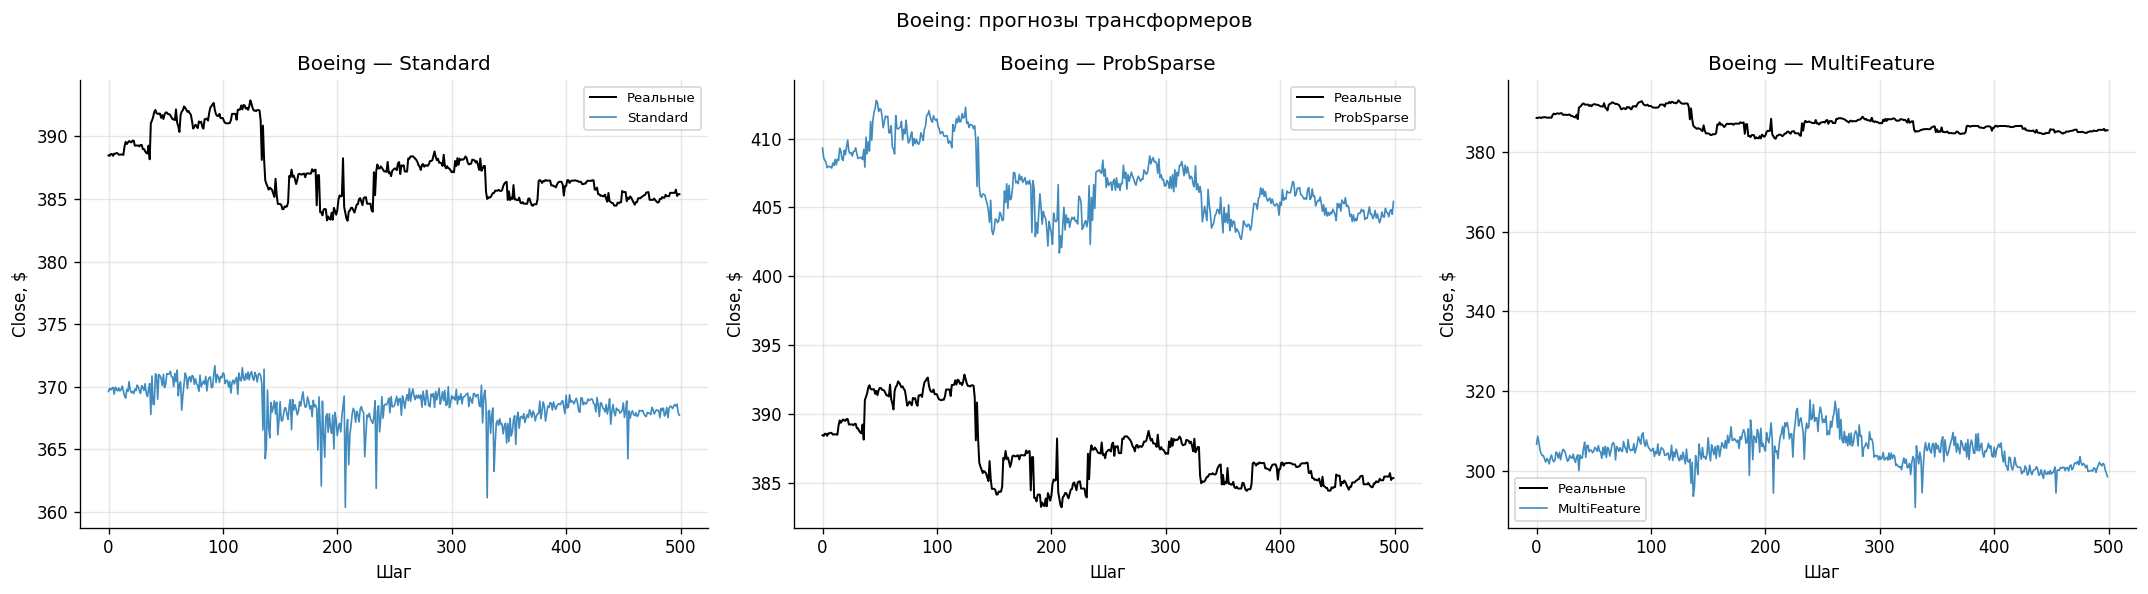

In [40]:
print("==================================================")
print("Boeing")
print("==================================================")
X_boeing, y_boeing_raw = preprocess_new_dataset(
    "boeing.csv", feature_scalers, target_scaler, features)
print(f"Последовательностей: {X_boeing.shape[0]}")

pred_boeing_std   = apply_model(std_transformer,   X_boeing, target_scaler)
pred_boeing_prob  = apply_model(prob_transformer,  X_boeing, target_scaler)
pred_boeing_multi = apply_model(multi_transformer, X_boeing, target_scaler)

boeing_res = pd.DataFrame([
    compute_metrics(y_boeing_raw, pred_boeing_std,   "Standard Transformer"),
    compute_metrics(y_boeing_raw, pred_boeing_prob,  "ProbSparse Transformer"),
    compute_metrics(y_boeing_raw, pred_boeing_multi, "MultiFeature Transformer"),
])[["Модель","MAE","RMSE","R²","DirAcc,%","TheilU2"]].round(4)
display(boeing_res)

N = N_PLOT
fig, axes = plt.subplots(1, 3, figsize=(18,5))
for ax, (nm, pred) in zip(axes, [
    ("Standard",    pred_boeing_std),
    ("ProbSparse",  pred_boeing_prob),
    ("MultiFeature",pred_boeing_multi)]):
    ax.plot(y_boeing_raw[:N], color="black", linewidth=1.2, label="Реальные")
    ax.plot(pred[:N], linewidth=1.0, label=nm, alpha=0.85)
    ax.set_title(f"Boeing — {nm}")
    ax.set_xlabel("Шаг"); ax.set_ylabel("Close, $"); ax.legend(fontsize=8)
plt.suptitle("Boeing: прогнозы трансформеров")
plt.tight_layout(); plt.show()


JP Morgan
Последовательностей: 159089


,Модель,MAE,RMSE,R²,"DirAcc,%",TheilU2
0,Standard Transformer,2.9509,3.2460,0.9513,43.6589,12.1001
1,ProbSparse Transformer,3.4717,3.8922,0.9300,42.7682,14.5088
2,MultiFeature Transformer,11.7433,12.7478,0.2488,43.1378,47.5194


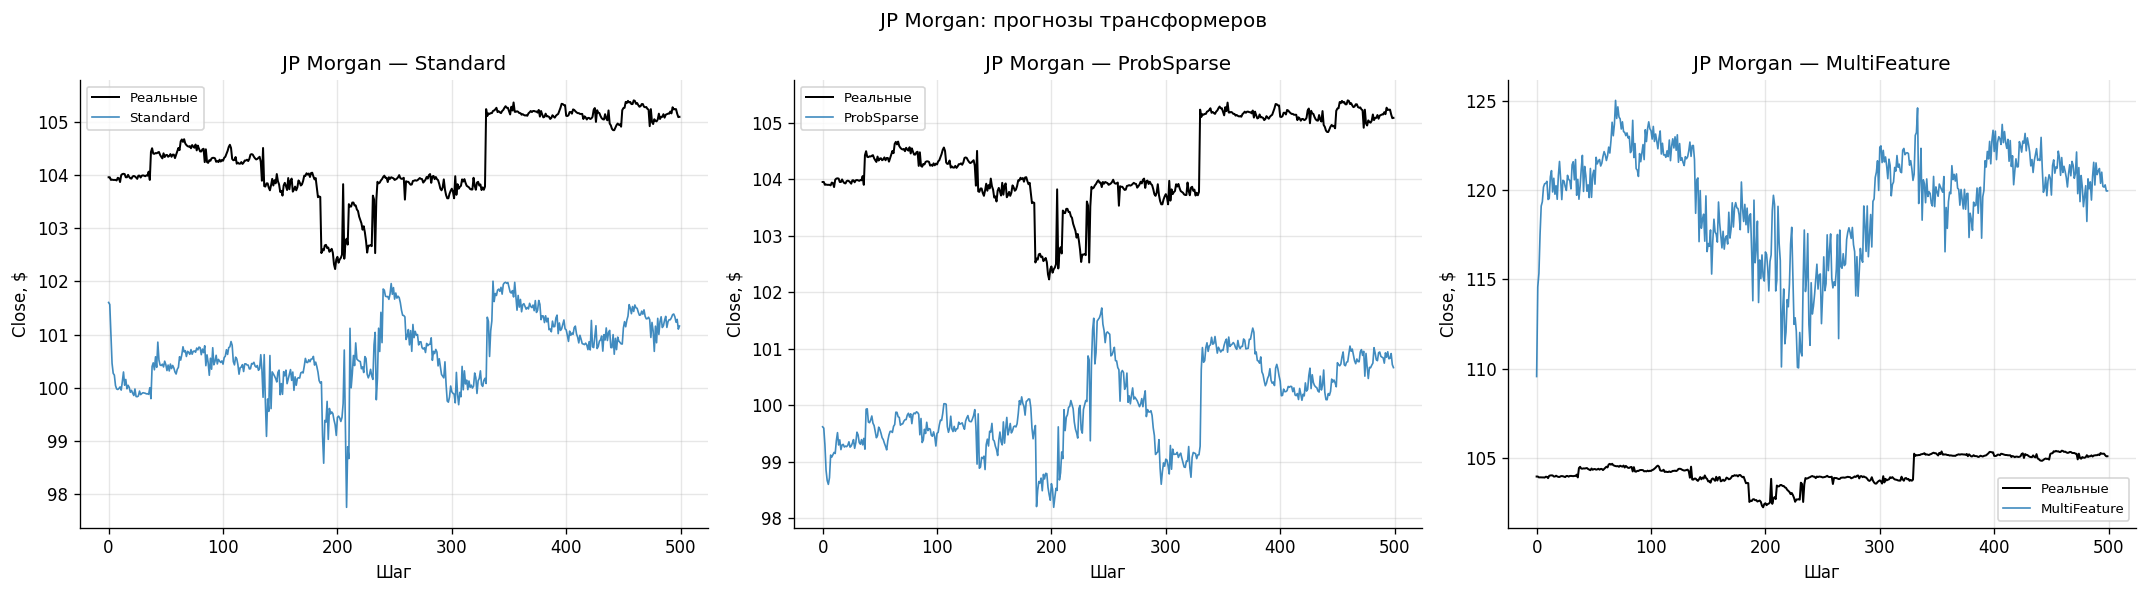

In [41]:
print("==================================================")
print("JP Morgan")
print("==================================================")
X_jp_morgan, y_jp_morgan_raw = preprocess_new_dataset(
    "jp_morgan.csv", feature_scalers, target_scaler, features)
print(f"Последовательностей: {X_jp_morgan.shape[0]}")

pred_jp_morgan_std   = apply_model(std_transformer,   X_jp_morgan, target_scaler)
pred_jp_morgan_prob  = apply_model(prob_transformer,  X_jp_morgan, target_scaler)
pred_jp_morgan_multi = apply_model(multi_transformer, X_jp_morgan, target_scaler)

jp_morgan_res = pd.DataFrame([
    compute_metrics(y_jp_morgan_raw, pred_jp_morgan_std,   "Standard Transformer"),
    compute_metrics(y_jp_morgan_raw, pred_jp_morgan_prob,  "ProbSparse Transformer"),
    compute_metrics(y_jp_morgan_raw, pred_jp_morgan_multi, "MultiFeature Transformer"),
])[["Модель","MAE","RMSE","R²","DirAcc,%","TheilU2"]].round(4)
display(jp_morgan_res)

N = N_PLOT
fig, axes = plt.subplots(1, 3, figsize=(18,5))
for ax, (nm, pred) in zip(axes, [
    ("Standard",    pred_jp_morgan_std),
    ("ProbSparse",  pred_jp_morgan_prob),
    ("MultiFeature",pred_jp_morgan_multi)]):
    ax.plot(y_jp_morgan_raw[:N], color="black", linewidth=1.2, label="Реальные")
    ax.plot(pred[:N], linewidth=1.0, label=nm, alpha=0.85)
    ax.set_title(f"JP Morgan — {nm}")
    ax.set_xlabel("Шаг"); ax.set_ylabel("Close, $"); ax.legend(fontsize=8)
plt.suptitle("JP Morgan: прогнозы трансформеров")
plt.tight_layout(); plt.show()


---
## 12. Out-of-sample прогноз (авторегрессия)

In [42]:
def autoregressive_forecast(model, last_window, n_steps, feature_scalers,
                             target_scaler, features):
    model.eval()
    window = last_window.copy().astype(np.float32)
    preds  = []
    cl_idx = features.index("close") if "close" in features else None
    cl_sc  = feature_scalers.get("close")
    with torch.no_grad():
        for _ in range(n_steps):
            xb      = torch.FloatTensor(window).unsqueeze(0).to(device)
            pred_sc = model(xb).cpu().item()
            pred_raw= target_scaler.inverse_transform([[pred_sc]])[0,0]
            preds.append(pred_raw)
            new_step = window[-1].copy()
            if cl_idx is not None and cl_sc is not None:
                new_step[cl_idx] = cl_sc.transform([[pred_raw]])[0,0]
            window = np.vstack([window[1:], new_step])
    return np.array(preds)

N_FORECAST    = 60
last_window   = X_test[-1]

print(f"Прогноз на {N_FORECAST} шагов вперёд...")
fc_std   = autoregressive_forecast(std_transformer,   last_window, N_FORECAST,
                                    feature_scalers, target_scaler, features)
fc_prob  = autoregressive_forecast(prob_transformer,  last_window, N_FORECAST,
                                    feature_scalers, target_scaler, features)
fc_multi = autoregressive_forecast(multi_transformer, last_window, N_FORECAST,
                                    feature_scalers, target_scaler, features)
print("Готово.")


Прогноз на 60 шагов вперёд...
Готово.


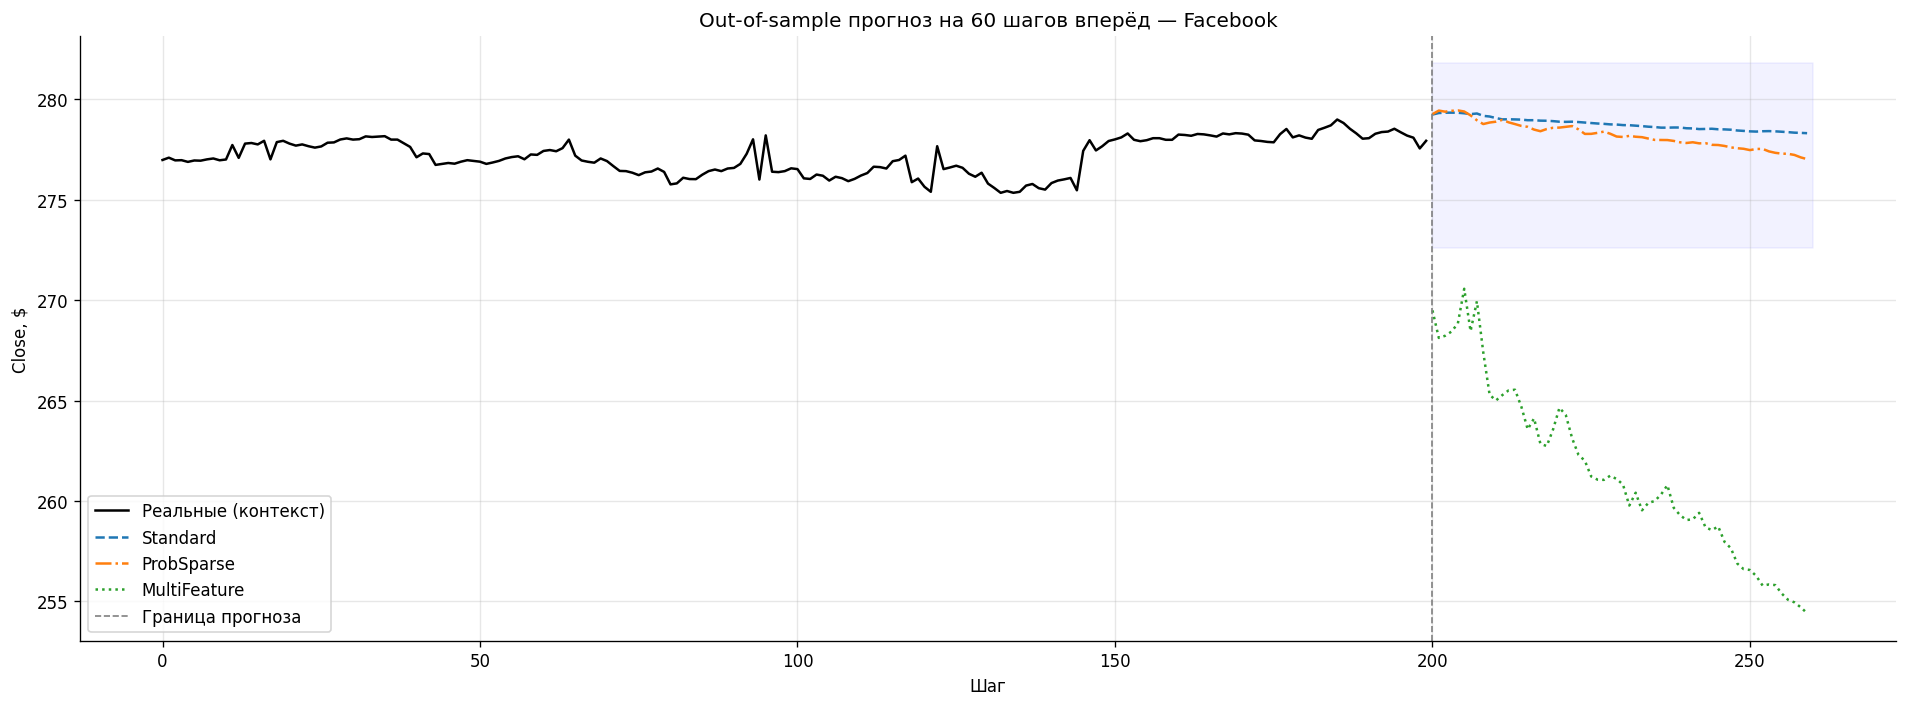

In [43]:
ctx  = 200
tail = y_true[-ctx:]

fig, ax = plt.subplots(figsize=(16,6))
ax.plot(np.arange(ctx), tail, color="black", linewidth=1.5, label="Реальные (контекст)")
x_fc = np.arange(ctx, ctx+N_FORECAST)
ax.plot(x_fc, fc_std,   label="Standard",    linewidth=1.5, linestyle="--")
ax.plot(x_fc, fc_prob,  label="ProbSparse",  linewidth=1.5, linestyle="-.")
ax.plot(x_fc, fc_multi, label="MultiFeature",linewidth=1.5, linestyle=":")
ax.axvline(ctx, color="gray", linestyle="--", linewidth=1, label="Граница прогноза")
ax.fill_betweenx([tail.min()*0.99, tail.max()*1.01], ctx, ctx+N_FORECAST,
                  alpha=0.05, color="blue")
ax.set_title(f"Out-of-sample прогноз на {N_FORECAST} шагов вперёд — Facebook")
ax.set_xlabel("Шаг"); ax.set_ylabel("Close, $"); ax.legend()
plt.tight_layout(); plt.show()


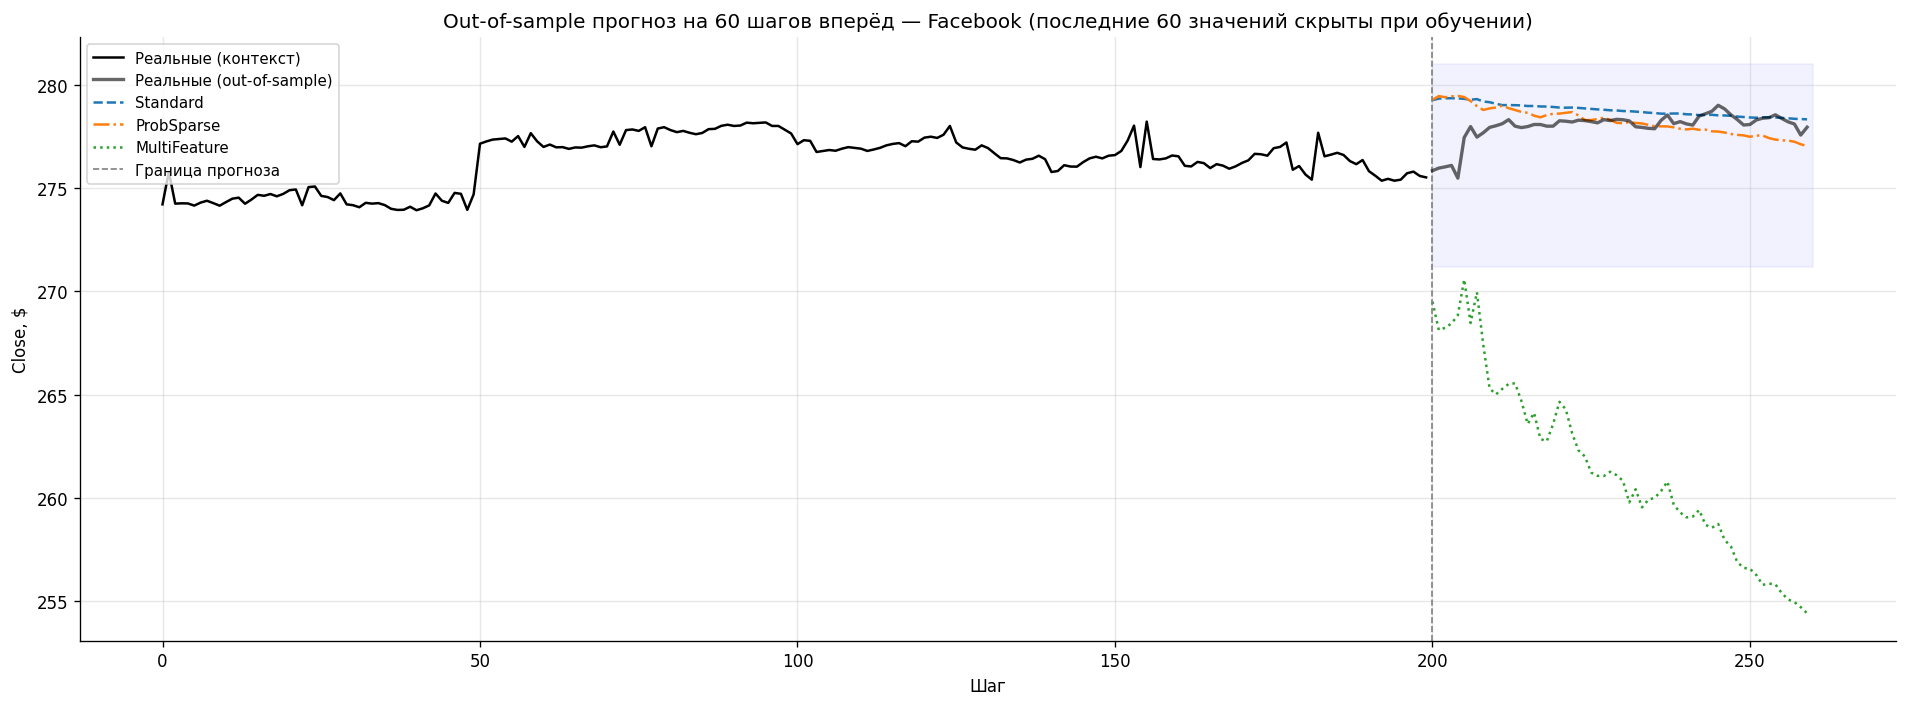

In [44]:
ctx  = 200
N_FORECAST = 60

# --- Разделение: последние 60 НЕ использовались при обучении ---
train_part = y_true[:-N_FORECAST]      # на этом обучались
true_fc    = y_true[-N_FORECAST:]      # реальные значения, которые были скрыты

# Контекст: последние ctx точек ДО границы прогноза
tail = train_part[-ctx:]                # вместо y_true[-ctx:]

fig, ax = plt.subplots(figsize=(16, 6))

# Контекст до границы
ax.plot(np.arange(ctx), tail, color="black", linewidth=1.5, label="Реальные (контекст)")

# Зона прогноза
x_fc = np.arange(ctx, ctx + N_FORECAST)

# РЕАЛЬНЫЕ значения, которые были скрыты при обучении
ax.plot(x_fc, true_fc, color="black", linewidth=2.0, linestyle="-",
        label="Реальные (out-of-sample)", alpha=0.6, zorder=5)

# Прогнозы моделей (получены на train_part, без подглядывания в true_fc)
ax.plot(x_fc, fc_std,    label="Standard",     linewidth=1.5, linestyle="--")
ax.plot(x_fc, fc_prob,   label="ProbSparse",   linewidth=1.5, linestyle="-.")
ax.plot(x_fc, fc_multi,  label="MultiFeature", linewidth=1.5, linestyle=":")

# Граница и подсветка — ваши, без изменений
ax.axvline(ctx, color="gray", linestyle="--", linewidth=1, label="Граница прогноза")
ax.fill_betweenx([tail.min()*0.99, tail.max()*1.01], ctx, ctx + N_FORECAST,
                   alpha=0.05, color="blue")

ax.set_title(f"Out-of-sample прогноз на {N_FORECAST} шагов вперёд — Facebook (последние {N_FORECAST} значений скрыты при обучении)")
ax.set_xlabel("Шаг")
ax.set_ylabel("Close, $")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

---
## 13. Итоговая сводная таблица

In [45]:
all_rows = []
for name, pred in [("Standard Transformer",pred_std),("ProbSparse Transformer",pred_prob),
                   ("MultiFeature Transformer",pred_multi),("LSTM",pred_lstm),
                   ("XGBoost",pred_xgb),("Random Forest",pred_rf)]:
    m = compute_metrics(y_true, pred, name); m["Датасет"] = "Facebook"; all_rows.append(m)
for name, pred in [("Standard Transformer",pred_boeing_std),
                   ("ProbSparse Transformer",pred_boeing_prob),
                   ("MultiFeature Transformer",pred_boeing_multi)]:
    m = compute_metrics(y_boeing_raw, pred, name); m["Датасет"] = "Boeing"; all_rows.append(m)
for name, pred in [("Standard Transformer",pred_jp_morgan_std),
                   ("ProbSparse Transformer",pred_jp_morgan_prob),
                   ("MultiFeature Transformer",pred_jp_morgan_multi)]:
    m = compute_metrics(y_jp_morgan_raw, pred, name); m["Датасет"] = "JP Morgan"; all_rows.append(m)

summ = pd.DataFrame(all_rows)[["Датасет","Модель","MAE","RMSE","R²","DirAcc,%","TheilU2","ACF1_err"]]
for c in ["MAE","RMSE","TheilU2","ACF1_err"]: summ[c] = summ[c].round(4)
summ["R²"]       = summ["R²"].round(5)
summ["DirAcc,%"] = summ["DirAcc,%"].round(2)

display(summ.style
    .background_gradient(subset=["R²"],       cmap="RdYlGn")
    .background_gradient(subset=["RMSE"],     cmap="RdYlGn_r")
    .background_gradient(subset=["DirAcc,%"], cmap="RdYlGn"))


,Датасет,Модель,MAE,RMSE,R²,"DirAcc,%",TheilU2,ACF1_err
0,Facebook,Standard Transformer,1.172900,1.865300,0.991060,47.500000,2.370400,0.547100
1,Facebook,ProbSparse Transformer,1.064900,1.745600,0.992170,53.220000,2.218200,0.702600
2,Facebook,MultiFeature Transformer,3.995400,6.136400,0.903250,47.820000,7.798000,0.794000
3,Facebook,LSTM,9.462000,12.715900,0.584540,49.690000,16.159000,0.985300
4,Facebook,XGBoost,23.731700,29.846600,-1.288860,54.300000,37.928200,0.998900
5,Facebook,Random Forest,21.182900,27.399400,-0.928910,50.860000,34.818400,0.998900
6,Boeing,Standard Transformer,3.685900,5.839100,0.996290,39.270000,6.726100,0.937900
7,Boeing,ProbSparse Transformer,9.286900,12.555800,0.982850,40.530000,14.463000,0.983800
8,Boeing,MultiFeature Transformer,29.814500,41.358900,0.813860,40.260000,47.641300,0.993600
9,JP Morgan,Standard Transformer,2.950900,3.246000,0.951290,43.660000,12.100100,0.871800
